# GRANDE W&B Diagnostics Analysis

This notebook turns the logged `grande_diagnostics/*` metrics into explicit tests for the failure modes documented in `grande_diagnostics_metric_reference.md`.

Failure modes covered:
- feature-selection collapse
- threshold collapse and threshold extremeness
- ensemble redundancy
- dead routing paths
- gradient pathologies
- context-seed instability

What this notebook does:
- checks whether each run actually logged the metrics needed for each failure mode
- compares initialization (`epoch=0`) against later epochs
- derives a few missing comparison metrics such as `backbone / decoder` gradient ratios
- builds per-run scorecards and focused per-depth tables
- reconstructs W&B histograms for a selected run

What this notebook does not do:
- prove root cause from diagnostics alone
- treat cached-batch diagnostics as evaluation metrics
- rely on hard universal thresholds when a metric scale depends on model configuration

The evidence scores below are heuristics for triage. A `strong lead` means the diagnostics give you a concrete hypothesis to validate next, not that the root cause is proven.

In [1]:
from __future__ import annotations

import math
import re
from textwrap import shorten
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wandb
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (11, 4.5)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 140)

ENTITY = "raiizen1-university-of-mannheim"
PROJECT = "tabflex_new"

RUN_PATHS = [
    # "raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_E50_grandedecodervariantfactorized_stats_grandediagnosticsTrue_nestimators64_n2048_treedepth4_0_6e1dcc9d4a65", # Fac, No-Grad
    # "raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_E50_grandedecodervariantfactorized_stats_grandediagnosticsTrue_grandediagnosticsgradientsTrue_n_ac9cd413a4d1",  # Fac, Grad
    # "raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_datasubsetfraction0.8_E50_grandedecodervariantfactorized_stats_grandediagnosticsTrue_grandediag_fd5b3759fe66",  # Fac, No-Grad, Subset
    # "raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_E50_grandedecodervariantdepthwise_factorized_stats_grandediagnosticsTrue_nestimators64_n2048_tr_1f4c48fa6612",  # Fac, Grad
    "raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_E50_grandedecodervariantfactorized_stats_grandediagnosticsTrue_grandediagnosticsgradientsTrue_g_ccb56ab3036d",  # Fac, Grad
]

# Alternative: leave RUN_PATHS empty and query the project with WANDB_FILTERS.
WANDB_FILTERS = None
MAX_RUNS = 12

FOCUS_RUN_PATH = None
FOCUS_EXTRA_HISTOGRAM_KEYS = (
    "grande_diagnostics/hists/effective_estimator_size",
    "grande_diagnostics/hists/leaf_occupancy",
    "grande_diagnostics/hists/backbone_param_grad_norms",
    "grande_diagnostics/hists/backbone_activation_grad_norms",
)

api = wandb.Api(timeout=120)

In [2]:
EPS = 1e-12
DEPTH_RE = re.compile(r"depth_(\d+)")
RUN_NAME_INT_PATTERNS = {
    "tree_depth": re.compile(r"(?:^|_)treedepth(?P<value>\d+)(?:_|$)"),
    "n_estimators": re.compile(r"(?:^|_)nestimators(?P<value>\d+)(?:_|$)"),
    "selected_variables": re.compile(r"(?:^|_)selectedvariables(?P<value>\d+)(?:_|$)"),
}
RUN_NAME_VARIANT_RE = re.compile(
    r"(?:^|_)grandedecodervariant(?P<value>[A-Za-z0-9_]+?)(?:_grandediagnostics|_nestimators|_n\d+|_treedepth|$)"
)


def safe_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def safe_div_scalar(numerator, denominator):
    numerator = safe_float(numerator)
    denominator = safe_float(denominator)
    if np.isnan(numerator) or np.isnan(denominator) or abs(denominator) < EPS:
        return np.nan
    return numerator / denominator


def clip01(value):
    value = safe_float(value)
    if np.isnan(value):
        return np.nan
    return float(np.clip(value, 0.0, 1.0))


def abs_high_score(value, center, scale):
    value = safe_float(value)
    if np.isnan(value):
        return np.nan
    return clip01((value - center) / max(scale, EPS))


def abs_low_score(value, center, scale):
    value = safe_float(value)
    if np.isnan(value):
        return np.nan
    return clip01((center - value) / max(scale, EPS))


def first_valid(series: pd.Series):
    series = pd.to_numeric(series, errors="coerce").dropna()
    if series.empty:
        return np.nan
    return float(series.iloc[0])


def last_valid(series: pd.Series):
    series = pd.to_numeric(series, errors="coerce").dropna()
    if series.empty:
        return np.nan
    return float(series.iloc[-1])


def pct_change(init_value, last_value):
    init_value = safe_float(init_value)
    last_value = safe_float(last_value)
    if np.isnan(init_value) or np.isnan(last_value):
        return np.nan
    return (last_value - init_value) / max(abs(init_value), EPS)


def trend_strength(init_value, last_value, bad_direction: str, scale: float = 0.25):
    change = pct_change(init_value, last_value)
    if np.isnan(change):
        return np.nan
    if bad_direction == "high":
        directional = max(change, 0.0)
    elif bad_direction == "low":
        directional = max(-change, 0.0)
    else:
        raise ValueError(f"unknown bad_direction: {bad_direction}")
    return clip01(directional / max(scale, EPS))


def score_from_components(components):
    values = [safe_float(value) for value in components]
    values = [value for value in values if not np.isnan(value)]
    if not values:
        return np.nan
    return float(np.mean(values))


def evidence_label(score):
    score = safe_float(score)
    if np.isnan(score):
        return "not testable"
    if score >= 0.67:
        return "strong lead"
    if score >= 0.40:
        return "watch"
    return "little evidence"


def compose_note(*parts):
    clean = [str(part) for part in parts if part not in (None, "") and not pd.isna(part)]
    return " | ".join(clean)


def parse_depth(key: str) -> int:
    match = DEPTH_RE.search(key)
    if match is None:
        raise ValueError(f"could not parse depth from key: {key}")
    return int(match.group(1))


def run_path_str(run) -> str:
    path = getattr(run, "path", None)
    if isinstance(path, (list, tuple)):
        return "/".join(path)
    return str(path)


def run_name_str(run) -> str:
    return getattr(run, "display_name", None) or getattr(run, "name", None) or run_path_str(run).split("/")[-1]


def config_first(config: dict, *keys, default=None):
    for key in keys:
        value = config.get(key)
        if value not in (None, ""):
            return value
    return default


def infer_run_name_int(run, field: str):
    pattern = RUN_NAME_INT_PATTERNS[field]
    match = pattern.search(run_name_str(run))
    if match is None:
        return np.nan
    return safe_float(match.group("value"))


def infer_run_name_variant(run) -> str | None:
    match = RUN_NAME_VARIANT_RE.search(run_name_str(run))
    if match is None:
        return None
    return match.group("value")


def run_label(run) -> str:
    config = dict(run.config)
    variant = (
        config_first(config, "mothernet_grande_decoder_variant", "grande_decoder_variant", "grandedecodervariant")
        or infer_run_name_variant(run)
        or "unknown"
    )
    short_name = shorten(run_name_str(run), width=48, placeholder="...")
    return f"{variant}:{short_name}"


def run_record(run) -> dict:
    config = dict(run.config)
    summary = dict(run.summary)
    variant = (
        config_first(config, "mothernet_grande_decoder_variant", "grande_decoder_variant", "grandedecodervariant")
        or infer_run_name_variant(run)
        or "unknown"
    )
    return {
        "run_path": run_path_str(run),
        "id": getattr(run, "id", None),
        "name": run_name_str(run),
        "label": run_label(run),
        "variant": variant,
        "tree_depth": safe_float(
            config_first(config, "mothernet_tree_depth", "tree_depth", default=infer_run_name_int(run, "tree_depth"))
        ),
        "n_estimators": safe_float(
            config_first(config, "mothernet_n_estimators", "n_estimators", default=infer_run_name_int(run, "n_estimators"))
        ),
        "selected_variables": safe_float(
            config_first(config, "mothernet_selected_variables", "selected_variables", default=infer_run_name_int(run, "selected_variables"))
        ),
        "state": getattr(run, "state", None),
        "created_at": getattr(run, "created_at", None),
        "gradient_metrics_enabled": safe_float(
            config_first(
                config,
                "mothernet_grande_diagnostics_gradients",
                "grande_diagnostics_gradients",
                default=summary.get("grande_diagnostics/meta/gradient_metrics_enabled"),
            )
        ),
    }


def resolve_runs(api, entity: str, project: str, run_paths: Sequence[str], filters, max_runs: int | None):
    if run_paths:
        return [api.run(path) for path in run_paths]
    if not filters:
        raise ValueError("Set RUN_PATHS or WANDB_FILTERS before running the notebook.")
    runs = list(api.runs(f"{entity}/{project}", filters=filters))
    if max_runs is not None:
        runs = runs[:max_runs]
    return runs


def list_grande_keys(run, include_histograms: bool = True) -> list[str]:
    keys = sorted(key for key in run.summary.keys() if key.startswith("grande_diagnostics/"))
    if include_histograms:
        return keys
    return [key for key in keys if "/hists/" not in key]


def existing_keys(run, keys: Sequence[str]) -> list[str]:
    available = set(run.summary.keys())
    return [key for key in keys if key in available]


def load_scalar_history(run, keys: Sequence[str] | None = None) -> pd.DataFrame:
    if keys is None:
        keys = list_grande_keys(run, include_histograms=False)
    present = existing_keys(run, keys)
    rows = list(run.scan_history(keys=["_step", *present], page_size=500))
    if not rows:
        return pd.DataFrame(columns=["_step", "epoch", *present])

    df = pd.DataFrame(rows).sort_values("_step").reset_index(drop=True)
    for column in df.columns:
        if column != "_step":
            df[column] = pd.to_numeric(df[column], errors="coerce")

    epoch_key = "grande_diagnostics/meta/epoch"
    if epoch_key in df.columns:
        df["epoch"] = df[epoch_key].fillna(df["_step"])
    else:
        df["epoch"] = df["_step"]

    df = df.groupby("epoch", as_index=False).last()
    if "_step" not in df.columns:
        df["_step"] = df["epoch"]
    return df.sort_values("epoch").reset_index(drop=True)


def enrich_history(df: pd.DataFrame, meta: dict) -> pd.DataFrame:
    df = df.copy()
    n_estimators = safe_float(meta.get("n_estimators"))
    tree_depth = safe_float(meta.get("tree_depth"))

    if n_estimators > 0:
        if "grande_diagnostics/diversity/effective_dim_95" in df.columns:
            df["derived/diversity/effective_dim_fraction"] = (
                df["grande_diagnostics/diversity/effective_dim_95"] / n_estimators
            )
        if "grande_diagnostics/estimator_weights/effective_size_mean" in df.columns:
            df["derived/estimator_weights/effective_size_fraction"] = (
                df["grande_diagnostics/estimator_weights/effective_size_mean"] / n_estimators
            )

    if tree_depth > 0 and "grande_diagnostics/routing/path_entropy_mean" in df.columns:
        max_path_entropy = math.log(2 ** int(tree_depth))
        if max_path_entropy > 0:
            df["derived/routing/path_entropy_fraction"] = (
                df["grande_diagnostics/routing/path_entropy_mean"] / max_path_entropy
            )

    if {
        "grande_diagnostics/context_seed/loss_std",
        "grande_diagnostics/context_seed/loss_mean",
    }.issubset(df.columns):
        denominator = df["grande_diagnostics/context_seed/loss_mean"].abs().replace(0.0, np.nan)
        df["derived/context_seed/loss_cv"] = (
            df["grande_diagnostics/context_seed/loss_std"] / denominator
        )

    if {
        "grande_diagnostics/gradients/params/backbone/l2_norm",
        "grande_diagnostics/gradients/params/decoder/l2_norm",
    }.issubset(df.columns):
        denominator = df["grande_diagnostics/gradients/params/decoder/l2_norm"].replace(0.0, np.nan)
        df["derived/gradients/backbone_to_decoder_l2_ratio"] = (
            df["grande_diagnostics/gradients/params/backbone/l2_norm"] / denominator
        )

    if {
        "grande_diagnostics/gradients/params/backbone/grad_to_weight_ratio",
        "grande_diagnostics/gradients/params/decoder/grad_to_weight_ratio",
    }.issubset(df.columns):
        denominator = df["grande_diagnostics/gradients/params/decoder/grad_to_weight_ratio"].replace(0.0, np.nan)
        df["derived/gradients/backbone_to_decoder_grad_to_weight_ratio"] = (
            df["grande_diagnostics/gradients/params/backbone/grad_to_weight_ratio"] / denominator
        )

    return df


def histogram_to_frame(run, key: str) -> pd.DataFrame:
    rows = list(
        run.scan_history(
            keys=["_step", "grande_diagnostics/meta/epoch", key],
            page_size=500,
        )
    )
    records = []
    for row in rows:
        hist = row.get(key)
        if not hist or hist.get("_type") != "histogram":
            continue
        bins = hist["bins"]
        values = hist["values"]
        step = row["_step"]
        epoch = row.get("grande_diagnostics/meta/epoch", step)
        for bin_idx, count in enumerate(values):
            left = bins[bin_idx]
            right = bins[bin_idx + 1] if bin_idx + 1 < len(bins) else bins[bin_idx]
            center = 0.5 * (left + right)
            records.append(
                {
                    "_step": step,
                    "epoch": epoch,
                    "bin_idx": bin_idx,
                    "bin_left": left,
                    "bin_right": right,
                    "bin_center": center,
                    "count": float(count),
                }
            )
    return pd.DataFrame.from_records(records)


def find_depth_keys(keys: Sequence[str], prefix: str, suffix: str) -> list[str]:
    matched = [key for key in keys if isinstance(key, str) and key.startswith(prefix) and key.endswith(suffix)]
    return sorted(matched, key=parse_depth)


def metric_series(history: pd.DataFrame, key: str) -> pd.Series:
    if key not in history.columns:
        return pd.Series(dtype=float)
    return pd.to_numeric(history[key], errors="coerce")


def metric_snapshot(history: pd.DataFrame, key: str) -> dict:
    series = metric_series(history, key)
    init_value = first_valid(series)
    last_value = last_valid(series)
    delta = np.nan
    if not np.isnan(init_value) and not np.isnan(last_value):
        delta = last_value - init_value
    return {
        "init": init_value,
        "last": last_value,
        "delta": delta,
        "pct_change": pct_change(init_value, last_value),
    }


def depth_metric_summary(history: pd.DataFrame, prefix: str, suffix: str, metric_name: str) -> pd.DataFrame:
    keys = find_depth_keys(history.columns, prefix=prefix, suffix=suffix)
    rows = []
    for key in keys:
        snapshot = metric_snapshot(history, key)
        rows.append(
            {
                "depth": parse_depth(key),
                "metric_key": key,
                "metric_name": metric_name,
                **snapshot,
            }
        )
    if not rows:
        return pd.DataFrame(columns=["depth", "metric_key", "metric_name", "init", "last", "delta", "pct_change"])
    return pd.DataFrame(rows).sort_values("depth").reset_index(drop=True)


def merge_depth_summaries(named_frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    merged = None
    for metric_name, frame in named_frames.items():
        if frame is None or frame.empty:
            continue
        renamed = frame.rename(
            columns={
                "init": f"{metric_name}_init",
                "last": f"{metric_name}_last",
                "delta": f"{metric_name}_delta",
                "pct_change": f"{metric_name}_pct_change",
            }
        )[[
            "depth",
            f"{metric_name}_init",
            f"{metric_name}_last",
            f"{metric_name}_delta",
            f"{metric_name}_pct_change",
        ]]
        merged = renamed if merged is None else merged.merge(renamed, on="depth", how="outer")
    if merged is None:
        return pd.DataFrame()
    return merged.sort_values("depth").reset_index(drop=True)


def deepest_root_ratio(history: pd.DataFrame, prefix: str, suffix: str) -> dict:
    keys = find_depth_keys(history.columns, prefix=prefix, suffix=suffix)
    if len(keys) < 2:
        return {"init": np.nan, "last": np.nan, "delta": np.nan, "pct_change": np.nan}
    root = metric_snapshot(history, keys[0])
    deep = metric_snapshot(history, keys[-1])
    init_ratio = safe_div_scalar(deep["init"], root["init"])
    last_ratio = safe_div_scalar(deep["last"], root["last"])
    return {
        "init": init_ratio,
        "last": last_ratio,
        "delta": last_ratio - init_ratio if not np.isnan(init_ratio) and not np.isnan(last_ratio) else np.nan,
        "pct_change": pct_change(init_ratio, last_ratio),
    }


def plot_metric_trends(histories: dict[str, pd.DataFrame], run_meta: pd.DataFrame, key: str, title: str, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    label_map = run_meta.set_index("run_path")["label"].to_dict()
    plotted = False
    for run_path, history in histories.items():
        if key not in history.columns:
            continue
        plot_df = history[["epoch", key]].dropna()
        if plot_df.empty:
            continue
        ax.plot(plot_df["epoch"], plot_df[key], marker="o", linewidth=2, alpha=0.9, label=label_map.get(run_path, run_path))
        plotted = True
    ax.set_title(title)
    ax.set_xlabel("epoch")
    if plotted:
        ax.legend(loc="best")
    else:
        ax.text(0.5, 0.5, "metric not present", ha="center", va="center", transform=ax.transAxes)


def plot_focus_depth_metric(history: pd.DataFrame, prefix: str, suffix: str, title: str, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    keys = find_depth_keys(history.columns, prefix=prefix, suffix=suffix)
    plotted = False
    for key in keys:
        depth = parse_depth(key)
        plot_df = history[["epoch", key]].dropna()
        if plot_df.empty:
            continue
        ax.plot(plot_df["epoch"], plot_df[key], marker="o", linewidth=2, alpha=0.9, label=f"depth {depth}")
        plotted = True
    ax.set_title(title)
    ax.set_xlabel("epoch")
    if plotted:
        ax.legend(loc="best")
    else:
        ax.text(0.5, 0.5, "metric not present", ha="center", va="center", transform=ax.transAxes)


def plot_histogram_heatmap(hist_df: pd.DataFrame, title: str, normalize: bool = True, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))
    if hist_df.empty:
        ax.text(0.5, 0.5, "histogram not present", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return
    plot_df = hist_df.copy()
    value_col = "count"
    if normalize:
        totals = plot_df.groupby("epoch")["count"].transform("sum").replace(0.0, np.nan)
        plot_df["density"] = plot_df["count"] / totals
        value_col = "density"
    pivot = plot_df.pivot_table(index="epoch", columns="bin_center", values=value_col, fill_value=0.0)
    sns.heatmap(pivot.sort_index(), cmap="viridis", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("bin center")
    ax.set_ylabel("epoch")


def plot_histogram_overlay(hist_df: pd.DataFrame, title: str, normalize: bool = True, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))
    if hist_df.empty:
        ax.text(0.5, 0.5, "histogram not present", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return
    first_epoch = hist_df["epoch"].min()
    last_epoch = hist_df["epoch"].max()
    for epoch in (first_epoch, last_epoch):
        epoch_df = hist_df[hist_df["epoch"] == epoch].sort_values("bin_center")
        y = epoch_df["count"].to_numpy(copy=True)
        if normalize and y.sum() > 0:
            y = y / y.sum()
        ax.plot(epoch_df["bin_center"], y, marker="o", linewidth=2, alpha=0.9, label=f"epoch {int(epoch)}")
    ax.set_title(title)
    ax.set_xlabel("bin center")
    ax.legend(loc="best")

In [3]:
MODE_SPECS = {
    "feature_selection_collapse": {
        "title": "Feature selection collapse",
        "required": [
            {"kind": "depth", "prefix": "grande_diagnostics/feature_selection/depth_", "suffix": "/entropy", "label": "entropy"},
            {"kind": "depth", "prefix": "grande_diagnostics/feature_selection/depth_", "suffix": "/unique_ratio", "label": "unique_ratio"},
            {"kind": "depth", "prefix": "grande_diagnostics/feature_selection/depth_", "suffix": "/concentration_hhi", "label": "concentration_hhi"},
        ],
    },
    "threshold_collapse": {
        "title": "Threshold collapse",
        "required": [
            {"kind": "depth", "prefix": "grande_diagnostics/thresholds/depth_", "suffix": "/std", "label": "std"},
            {"kind": "depth", "prefix": "grande_diagnostics/thresholds/depth_", "suffix": "/variance", "label": "variance"},
            {"kind": "depth", "prefix": "grande_diagnostics/thresholds/depth_", "suffix": "/zscore_abs_mean", "label": "zscore_abs_mean"},
            {"kind": "depth", "prefix": "grande_diagnostics/thresholds/depth_", "suffix": "/extreme_fraction_abs_z_gt_3", "label": "extreme_fraction_abs_z_gt_3"},
        ],
    },
    "ensemble_redundancy": {
        "title": "Ensemble redundancy",
        "required": [
            {"kind": "exact", "key": "grande_diagnostics/diversity/split_index_cosine_mean", "label": "split_index_cosine_mean"},
            {"kind": "exact", "key": "grande_diagnostics/diversity/threshold_cosine_mean", "label": "threshold_cosine_mean"},
            {"kind": "exact", "key": "grande_diagnostics/diversity/leaf_cosine_mean", "label": "leaf_cosine_mean"},
            {"kind": "exact", "key": "grande_diagnostics/diversity/effective_dim_95", "label": "effective_dim_95"},
        ],
    },
    "dead_routing_paths": {
        "title": "Dead routing paths",
        "required": [
            {"kind": "exact", "key": "grande_diagnostics/routing/path_entropy_mean", "label": "path_entropy_mean"},
            {"kind": "exact", "key": "grande_diagnostics/routing/dead_leaf_fraction", "label": "dead_leaf_fraction"},
        ],
    },
    "gradient_pathologies": {
        "title": "Gradient pathologies",
        "required": [
            {"kind": "exact", "key": "grande_diagnostics/gradients/params/backbone/l2_norm", "label": "backbone_l2_norm"},
            {"kind": "exact", "key": "grande_diagnostics/gradients/params/decoder/l2_norm", "label": "decoder_l2_norm"},
            {"kind": "depth", "prefix": "grande_diagnostics/gradients/per_depth/split_values_depth_", "suffix": "_l2_norm", "label": "split_values_depth_grad"},
            {"kind": "depth", "prefix": "grande_diagnostics/gradients/per_depth/split_index_logits_depth_", "suffix": "_l2_norm", "label": "split_index_depth_grad"},
        ],
    },
    "seed_instability": {
        "title": "Seed instability",
        "required": [
            {"kind": "exact", "key": "grande_diagnostics/context_seed/loss_std", "label": "loss_std"},
            {"kind": "exact", "key": "grande_diagnostics/context_seed/loss_range", "label": "loss_range"},
            {"kind": "exact", "key": "grande_diagnostics/context_seed/probability_variance_mean", "label": "probability_variance_mean"},
            {"kind": "exact", "key": "grande_diagnostics/context_seed/prediction_agreement_mean", "label": "prediction_agreement_mean"},
        ],
    },
}
MODE_ORDER = list(MODE_SPECS)


def requirement_matches(keys: Sequence[str], requirement: dict) -> list[str]:
    if requirement["kind"] == "exact":
        return [requirement["key"]] if requirement["key"] in keys else []
    if requirement["kind"] == "depth":
        return find_depth_keys(keys, requirement["prefix"], requirement["suffix"])
    raise ValueError(f"unknown requirement kind: {requirement['kind']}")


def build_coverage_table(run_key_map: dict[str, list[str]]) -> pd.DataFrame:
    rows = []
    for run_path, keys in run_key_map.items():
        keys = list(keys)
        for mode, spec in MODE_SPECS.items():
            present = 0
            missing = []
            for requirement in spec["required"]:
                matches = requirement_matches(keys, requirement)
                if matches:
                    present += 1
                else:
                    missing.append(requirement["label"])
            coverage = present / max(len(spec["required"]), 1)
            rows.append(
                {
                    "run_path": run_path,
                    "mode": mode,
                    "mode_title": spec["title"],
                    "coverage": coverage,
                    "missing_keys": ", ".join(missing),
                }
            )
    return pd.DataFrame(rows)


def assess_feature_selection(meta: dict, history: pd.DataFrame):
    detail = merge_depth_summaries(
        {
            "entropy": depth_metric_summary(history, "grande_diagnostics/feature_selection/depth_", "/entropy", "entropy"),
            "unique_ratio": depth_metric_summary(history, "grande_diagnostics/feature_selection/depth_", "/unique_ratio", "unique_ratio"),
            "concentration_hhi": depth_metric_summary(history, "grande_diagnostics/feature_selection/depth_", "/concentration_hhi", "concentration_hhi"),
        }
    )
    if detail.empty:
        return {"mode": "feature_selection_collapse", "score": np.nan, "note": "missing feature-selection metrics"}, detail

    selected_variables = safe_float(meta.get("selected_variables"))
    if selected_variables > 1:
        detail["entropy_norm_last"] = detail["entropy_last"] / math.log(selected_variables)
    else:
        detail["entropy_norm_last"] = np.nan

    detail["entropy_drop_strength"] = detail.apply(lambda row: trend_strength(row["entropy_init"], row["entropy_last"], "low"), axis=1)
    detail["unique_drop_strength"] = detail.apply(lambda row: trend_strength(row["unique_ratio_init"], row["unique_ratio_last"], "low"), axis=1)
    detail["hhi_rise_strength"] = detail.apply(lambda row: trend_strength(row["concentration_hhi_init"], row["concentration_hhi_last"], "high"), axis=1)
    detail["entropy_low_abs"] = detail["entropy_norm_last"].apply(lambda value: abs_low_score(value, 0.55, 0.35))
    detail["collapse_evidence"] = detail[["entropy_drop_strength", "unique_drop_strength", "hhi_rise_strength", "entropy_low_abs"]].mean(axis=1, skipna=True)

    worst = detail.sort_values("collapse_evidence", ascending=False).iloc[0]
    score = score_from_components(
        [
            detail["entropy_drop_strength"].mean(),
            detail["unique_drop_strength"].mean(),
            detail["hhi_rise_strength"].mean(),
            detail["entropy_low_abs"].mean(),
        ]
    )
    note = compose_note(
        f"worst depth {int(worst['depth'])}",
        f"entropy={safe_float(worst['entropy_last']):.3f}",
        f"unique_ratio={safe_float(worst['unique_ratio_last']):.3f}",
        f"hhi={safe_float(worst['concentration_hhi_last']):.3f}",
        None if np.isnan(safe_float(worst.get("entropy_norm_last"))) else f"norm_entropy={safe_float(worst['entropy_norm_last']):.3f}",
    )
    return {"mode": "feature_selection_collapse", "score": score, "note": note}, detail


def assess_thresholds(meta: dict, history: pd.DataFrame):
    detail = merge_depth_summaries(
        {
            "std": depth_metric_summary(history, "grande_diagnostics/thresholds/depth_", "/std", "std"),
            "variance": depth_metric_summary(history, "grande_diagnostics/thresholds/depth_", "/variance", "variance"),
            "zscore_abs_mean": depth_metric_summary(history, "grande_diagnostics/thresholds/depth_", "/zscore_abs_mean", "zscore_abs_mean"),
            "extreme_fraction_abs_z_gt_3": depth_metric_summary(history, "grande_diagnostics/thresholds/depth_", "/extreme_fraction_abs_z_gt_3", "extreme_fraction_abs_z_gt_3"),
        }
    )
    if detail.empty:
        return {"mode": "threshold_collapse", "score": np.nan, "note": "missing threshold metrics"}, detail

    detail["std_drop_strength"] = detail.apply(lambda row: trend_strength(row["std_init"], row["std_last"], "low", scale=0.40), axis=1)
    detail["variance_drop_strength"] = detail.apply(lambda row: trend_strength(row["variance_init"], row["variance_last"], "low", scale=0.50), axis=1)
    detail["collapse_evidence"] = detail[["std_drop_strength", "variance_drop_strength"]].mean(axis=1, skipna=True)

    worst = detail.sort_values("collapse_evidence", ascending=False).iloc[0]
    score = score_from_components(
        [
            detail["std_drop_strength"].mean(),
            detail["variance_drop_strength"].mean(),
        ]
    )
    note = compose_note(
        f"worst depth {int(worst['depth'])}",
        f"std={safe_float(worst['std_last']):.4g}",
        f"variance={safe_float(worst['variance_last']):.4g}",
        f"|z|_mean={safe_float(worst['zscore_abs_mean_last']):.3f}",
        f"frac(|z|>3)={safe_float(worst['extreme_fraction_abs_z_gt_3_last']):.3f}",
    )
    return {"mode": "threshold_collapse", "score": score, "note": note}, detail


def assess_ensemble(meta: dict, history: pd.DataFrame):
    split_cos = metric_snapshot(history, "grande_diagnostics/diversity/split_index_cosine_mean")
    threshold_cos = metric_snapshot(history, "grande_diagnostics/diversity/threshold_cosine_mean")
    leaf_cos = metric_snapshot(history, "grande_diagnostics/diversity/leaf_cosine_mean")
    eff_dim_frac = metric_snapshot(history, "derived/diversity/effective_dim_fraction")
    eff_size_frac = metric_snapshot(history, "derived/estimator_weights/effective_size_fraction")

    score = score_from_components(
        [
            abs_high_score(split_cos["last"], 0.65, 0.25),
            abs_high_score(threshold_cos["last"], 0.65, 0.25),
            abs_high_score(leaf_cos["last"], 0.65, 0.25),
            abs_low_score(eff_dim_frac["last"], 0.45, 0.30),
            trend_strength(eff_dim_frac["init"], eff_dim_frac["last"], "low", scale=0.35),
            abs_low_score(eff_size_frac["last"], 0.45, 0.30),
        ]
    )
    note = compose_note(
        f"split_cos={safe_float(split_cos['last']):.3f}",
        f"threshold_cos={safe_float(threshold_cos['last']):.3f}",
        f"leaf_cos={safe_float(leaf_cos['last']):.3f}",
        f"eff_dim_frac={safe_float(eff_dim_frac['last']):.3f}",
        f"eff_size_frac={safe_float(eff_size_frac['last']):.3f}",
    )
    return {"mode": "ensemble_redundancy", "score": score, "note": note}, pd.DataFrame()


def assess_routing(meta: dict, history: pd.DataFrame):
    dead_leaf = metric_snapshot(history, "grande_diagnostics/routing/dead_leaf_fraction")
    path_entropy_frac = metric_snapshot(history, "derived/routing/path_entropy_fraction")
    leaf_occupancy = metric_snapshot(history, "grande_diagnostics/routing/leaf_occupancy_mean")

    score = score_from_components(
        [
            abs_high_score(dead_leaf["last"], 0.10, 0.40),
            trend_strength(dead_leaf["init"], dead_leaf["last"], "high", scale=0.40),
            abs_low_score(path_entropy_frac["last"], 0.55, 0.35),
            trend_strength(path_entropy_frac["init"], path_entropy_frac["last"], "low", scale=0.25),
        ]
    )
    note = compose_note(
        f"dead_leaf_fraction={safe_float(dead_leaf['last']):.3f}",
        f"path_entropy_frac={safe_float(path_entropy_frac['last']):.3f}",
        f"leaf_occupancy_mean={safe_float(leaf_occupancy['last']):.4f}",
    )
    return {"mode": "dead_routing_paths", "score": score, "note": note}, pd.DataFrame()


def assess_seed(meta: dict, history: pd.DataFrame):
    loss_cv = metric_snapshot(history, "derived/context_seed/loss_cv")
    agreement = metric_snapshot(history, "grande_diagnostics/context_seed/prediction_agreement_mean")
    prob_var = metric_snapshot(history, "grande_diagnostics/context_seed/probability_variance_mean")

    score = score_from_components(
        [
            abs_high_score(loss_cv["last"], 0.05, 0.10),
            abs_low_score(agreement["last"], 0.95, 0.10),
            abs_high_score(prob_var["last"], 0.01, 0.02),
            trend_strength(loss_cv["init"], loss_cv["last"], "high", scale=0.40),
            trend_strength(agreement["init"], agreement["last"], "low", scale=0.10),
        ]
    )
    note = compose_note(
        f"loss_cv={safe_float(loss_cv['last']):.3f}",
        f"prediction_agreement={safe_float(agreement['last']):.3f}",
        f"probability_variance_mean={safe_float(prob_var['last']):.4f}",
    )
    return {"mode": "seed_instability", "score": score, "note": note}, pd.DataFrame()


def assess_gradients(meta: dict, history: pd.DataFrame):
    detail = merge_depth_summaries(
        {
            "split_values_grad": depth_metric_summary(history, "grande_diagnostics/gradients/per_depth/split_values_depth_", "_l2_norm", "split_values_grad"),
            "split_index_grad": depth_metric_summary(history, "grande_diagnostics/gradients/per_depth/split_index_logits_depth_", "_l2_norm", "split_index_grad"),
        }
    )
    if detail.empty and "derived/gradients/backbone_to_decoder_l2_ratio" not in history.columns:
        return {"mode": "gradient_pathologies", "score": np.nan, "note": "gradient diagnostics are not present"}, detail

    backbone_to_decoder = metric_snapshot(history, "derived/gradients/backbone_to_decoder_l2_ratio")
    backbone_to_decoder_gtw = metric_snapshot(history, "derived/gradients/backbone_to_decoder_grad_to_weight_ratio")
    split_values_ratio = deepest_root_ratio(history, "grande_diagnostics/gradients/per_depth/split_values_depth_", "_l2_norm")
    split_index_ratio = deepest_root_ratio(history, "grande_diagnostics/gradients/per_depth/split_index_logits_depth_", "_l2_norm")
    backbone_gtw = metric_snapshot(history, "grande_diagnostics/gradients/params/backbone/grad_to_weight_ratio")
    decoder_gtw = metric_snapshot(history, "grande_diagnostics/gradients/params/decoder/grad_to_weight_ratio")

    instability_last = np.nanmax([backbone_gtw["last"], decoder_gtw["last"]])
    score = score_from_components(
        [
            abs_low_score(backbone_to_decoder["last"], 0.50, 0.35),
            abs_low_score(split_values_ratio["last"], 0.50, 0.35),
            abs_low_score(split_index_ratio["last"], 0.50, 0.35),
            abs_high_score(instability_last, 1.00, 2.00),
        ]
    )
    note = compose_note(
        f"backbone/decoder_l2={safe_float(backbone_to_decoder['last']):.3f}",
        f"deep/root_split_values={safe_float(split_values_ratio['last']):.3f}",
        f"deep/root_split_index={safe_float(split_index_ratio['last']):.3f}",
        f"backbone/decoder_gtw={safe_float(backbone_to_decoder_gtw['last']):.3f}",
        f"max_grad_to_weight={safe_float(instability_last):.3f}",
    )
    return {"mode": "gradient_pathologies", "score": score, "note": note}, detail


ASSESSORS = {
    "feature_selection_collapse": assess_feature_selection,
    "threshold_collapse": assess_thresholds,
    "ensemble_redundancy": assess_ensemble,
    "dead_routing_paths": assess_routing,
    "gradient_pathologies": assess_gradients,
    "seed_instability": assess_seed,
}


def assess_all_modes(meta: dict, history: pd.DataFrame):
    summaries = []
    details = {}
    for mode in MODE_ORDER:
        assessor = ASSESSORS[mode]
        summary, detail = assessor(meta, history)
        summary["run_path"] = meta["run_path"]
        summary["label"] = meta["label"]
        summary["variant"] = meta["variant"]
        summary["mode_title"] = MODE_SPECS[mode]["title"]
        summary["verdict"] = evidence_label(summary["score"])
        summaries.append(summary)
        details[mode] = detail
    return summaries, details

In [4]:
runs = resolve_runs(api, ENTITY, PROJECT, RUN_PATHS, WANDB_FILTERS, MAX_RUNS)
if not runs:
    raise ValueError("No runs resolved. Update RUN_PATHS or WANDB_FILTERS.")

run_meta = pd.DataFrame([run_record(run) for run in runs]).sort_values(["variant", "created_at", "run_path"]).reset_index(drop=True)
run_key_map = {run_path_str(run): list_grande_keys(run, include_histograms=True) for run in runs}

scalar_histories = {}
for run in runs:
    meta = run_meta.loc[run_meta["run_path"] == run_path_str(run)].iloc[0].to_dict()
    scalar_histories[run_path_str(run)] = enrich_history(load_scalar_history(run), meta)

run_meta["num_scalar_keys"] = run_meta["run_path"].map(lambda path: sum(1 for key in run_key_map[path] if "/hists/" not in key))
run_meta["num_hist_keys"] = run_meta["run_path"].map(lambda path: sum(1 for key in run_key_map[path] if "/hists/" in key))
run_meta["num_history_rows"] = run_meta["run_path"].map(lambda path: len(scalar_histories[path]))

focus_run_path = FOCUS_RUN_PATH or run_meta.iloc[0]["run_path"]
focus_run = next(run for run in runs if run_path_str(run) == focus_run_path)
focus_history = scalar_histories[focus_run_path]
focus_label = run_meta.loc[run_meta["run_path"] == focus_run_path, "label"].iloc[0]

coverage_df = build_coverage_table(run_key_map)
score_rows = []
detail_store = {}
for _, meta_row in run_meta.iterrows():
    summaries, details = assess_all_modes(meta_row.to_dict(), scalar_histories[meta_row["run_path"]])
    score_rows.extend(summaries)
    detail_store[meta_row["run_path"]] = details

scorecard = pd.DataFrame(score_rows).merge(
    coverage_df[["run_path", "mode", "coverage", "missing_keys"]],
    on=["run_path", "mode"],
    how="left",
)
scorecard = scorecard[["run_path", "label", "variant", "mode", "mode_title", "coverage", "score", "verdict", "note", "missing_keys"]]

print(f"Loaded {len(runs)} run(s). Focus run: {focus_label}")
display(
    run_meta[
        [
            "label",
            "variant",
            "tree_depth",
            "n_estimators",
            "selected_variables",
            "state",
            "num_history_rows",
            "num_scalar_keys",
            "num_hist_keys",
        ]
    ]
)
coverage_pivot = coverage_df.merge(
    run_meta[["run_path", "label"]], on="run_path", how="left"
).pivot(index="label", columns="mode_title", values="coverage")
display(coverage_pivot)
display(scorecard.sort_values(["mode_title", "score"], ascending=[True, False]).reset_index(drop=True))

Loaded 1 run(s). Focus run: factorized_stats:...


/tmp/ipykernel_3195283/95895928.py:234: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["epoch"] = df[epoch_key].fillna(df["_step"])
/tmp/ipykernel_3195283/95895928.py:238: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.groupby("epoch", as_index=False).last()


,label,variant,tree_depth,n_estimators,selected_variables,state,num_history_rows,num_scalar_keys,num_hist_keys
0,factorized_stats:...,factorized_stats,4.0,64.0,16.0,finished,51,271,12


mode_title,Dead routing paths,Ensemble redundancy,Feature selection collapse,Gradient pathologies,Seed instability,Threshold collapse
label,,,,,,
factorized_stats:...,1.0,1.0,1.0,1.0,1.0,1.0


,run_path,label,variant,mode,mode_title,coverage,score,verdict,note,missing_keys
0,raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_E50_grandedecodervariantfactorized_stats_grandediagnosticsTrue_grandedia...,factorized_stats:...,factorized_stats,dead_routing_paths,Dead routing paths,1.0,0.750000,strong lead,dead_leaf_fraction=0.568 | path_entropy_frac=0.000 | leaf_occupancy_mean=0.0625,
1,raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_E50_grandedecodervariantfactorized_stats_grandediagnosticsTrue_grandedia...,factorized_stats:...,factorized_stats,ensemble_redundancy,Ensemble redundancy,1.0,0.135743,little evidence,split_cos=-0.005 | threshold_cos=0.154 | leaf_cos=0.740 | eff_dim_frac=0.734 | eff_size_frac=0.486,
2,raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_E50_grandedecodervariantfactorized_stats_grandediagnosticsTrue_grandedia...,factorized_stats:...,factorized_stats,feature_selection_collapse,Feature selection collapse,1.0,0.425593,watch,worst depth 0 | entropy=1.729 | unique_ratio=0.504 | hhi=0.047 | norm_entropy=0.623,
3,raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_E50_grandedecodervariantfactorized_stats_grandediagnosticsTrue_grandedia...,factorized_stats:...,factorized_stats,gradient_pathologies,Gradient pathologies,1.0,0.089622,little evidence,backbone/decoder_l2=0.598 | deep/root_split_values=0.375 | deep/root_split_index=0.579 | backbone/decoder_gtw=1.354 | max_grad_to_weight...,
4,raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_E50_grandedecodervariantfactorized_stats_grandediagnosticsTrue_grandedia...,factorized_stats:...,factorized_stats,seed_instability,Seed instability,1.0,0.263090,little evidence,loss_cv=0.011 | prediction_agreement=0.918 | probability_variance_mean=0.0004,
5,raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_E50_grandedecodervariantfactorized_stats_grandediagnosticsTrue_grandedia...,factorized_stats:...,factorized_stats,threshold_collapse,Threshold collapse,1.0,0.000000,little evidence,worst depth 0 | std=3.535 | variance=12.5 | |z|_mean=1.944 | frac(|z|>3)=0.293,


,label,variant,loss,accuracy,effective_dim_fraction,effective_size_fraction,dead_leaf_fraction,path_entropy_fraction,seed_loss_cv,prediction_agreement
0,factorized_stats:...,factorized_stats,0.8606,0.6128,0.7344,0.4856,0.5679,0.0,0.0114,0.9185


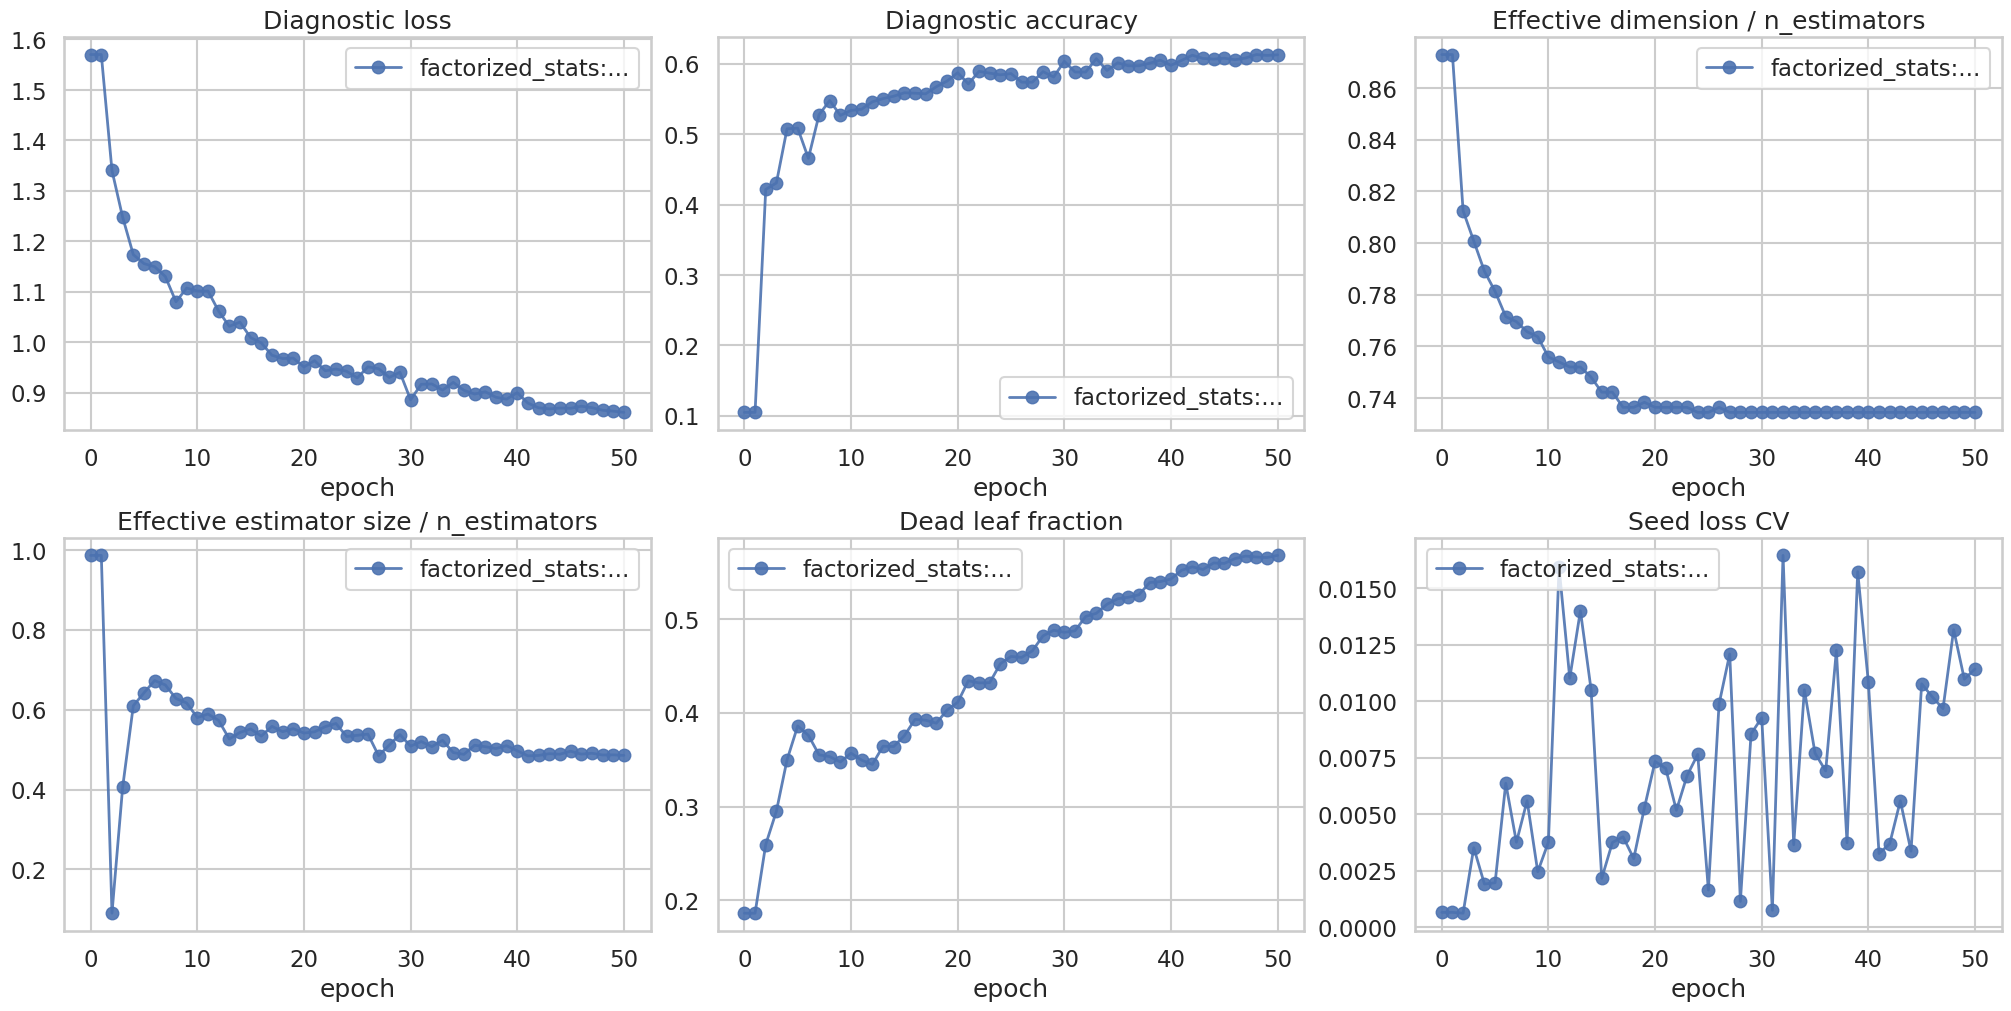

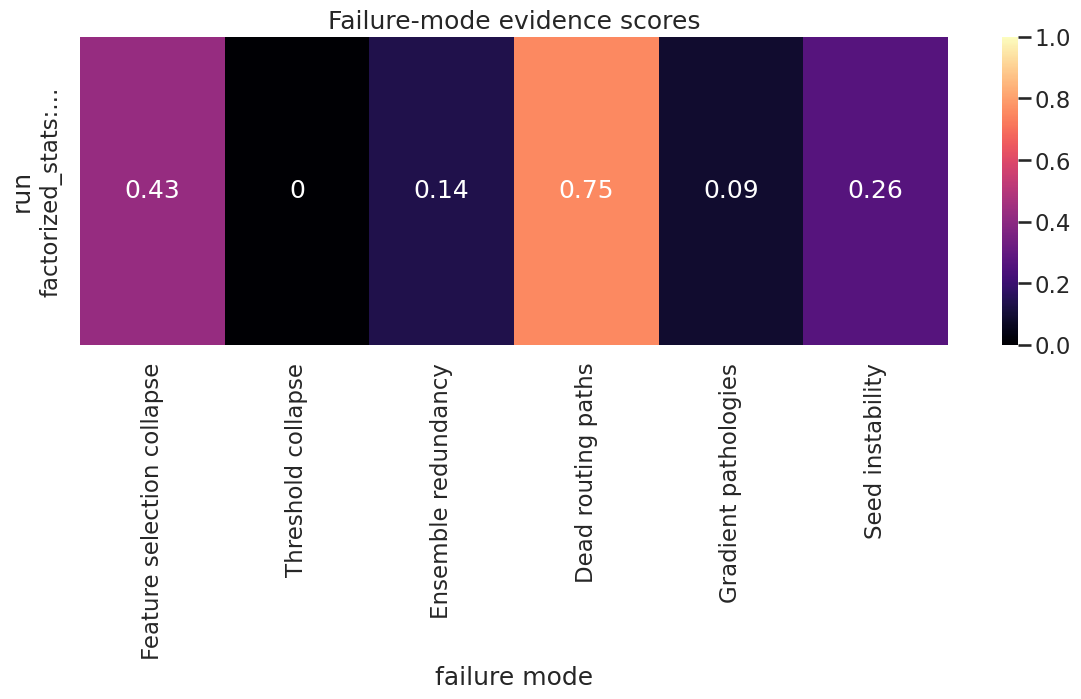

In [5]:
def final_metric_table(run_meta: pd.DataFrame, histories: dict[str, pd.DataFrame], metric_map: dict[str, str]) -> pd.DataFrame:
    rows = []
    for _, row in run_meta.iterrows():
        history = histories[row["run_path"]]
        record = {"label": row["label"], "variant": row["variant"]}
        for output_name, metric_key in metric_map.items():
            record[output_name] = metric_snapshot(history, metric_key)["last"]
        rows.append(record)
    return pd.DataFrame(rows)


overview_table = final_metric_table(
    run_meta,
    scalar_histories,
    {
        "loss": "grande_diagnostics/output/loss",
        "accuracy": "grande_diagnostics/output/accuracy",
        "effective_dim_fraction": "derived/diversity/effective_dim_fraction",
        "effective_size_fraction": "derived/estimator_weights/effective_size_fraction",
        "dead_leaf_fraction": "grande_diagnostics/routing/dead_leaf_fraction",
        "path_entropy_fraction": "derived/routing/path_entropy_fraction",
        "seed_loss_cv": "derived/context_seed/loss_cv",
        "prediction_agreement": "grande_diagnostics/context_seed/prediction_agreement_mean",
    },
)
display(overview_table.round(4))

score_heatmap = (
    scorecard.pivot(index="label", columns="mode_title", values="score")
    .reindex(columns=[MODE_SPECS[mode]["title"] for mode in MODE_ORDER])
)
fig, axes = plt.subplots(2, 3, figsize=(20, 10), constrained_layout=True)
plot_metric_trends(scalar_histories, run_meta, "grande_diagnostics/output/loss", "Diagnostic loss", ax=axes[0, 0])
plot_metric_trends(scalar_histories, run_meta, "grande_diagnostics/output/accuracy", "Diagnostic accuracy", ax=axes[0, 1])
plot_metric_trends(scalar_histories, run_meta, "derived/diversity/effective_dim_fraction", "Effective dimension / n_estimators", ax=axes[0, 2])
plot_metric_trends(scalar_histories, run_meta, "derived/estimator_weights/effective_size_fraction", "Effective estimator size / n_estimators", ax=axes[1, 0])
plot_metric_trends(scalar_histories, run_meta, "grande_diagnostics/routing/dead_leaf_fraction", "Dead leaf fraction", ax=axes[1, 1])
plot_metric_trends(scalar_histories, run_meta, "derived/context_seed/loss_cv", "Seed loss CV", ax=axes[1, 2])
plt.show()

plt.figure(figsize=(14, max(4, 0.6 * len(score_heatmap))))
sns.heatmap(score_heatmap, annot=True, cmap="magma", vmin=0.0, vmax=1.0)
plt.title("Failure-mode evidence scores")
plt.xlabel("failure mode")
plt.ylabel("run")
plt.show()

,run_path,label,variant,mode,mode_title,coverage,score,verdict,note,missing_keys
0,raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_E50_grandedecodervariantfactorized_stats_grandediagnosticsTrue_grandedia...,factorized_stats:...,factorized_stats,feature_selection_collapse,Feature selection collapse,1.0,0.425593,watch,worst depth 0 | entropy=1.729 | unique_ratio=0.504 | hhi=0.047 | norm_entropy=0.623,
1,raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_E50_grandedecodervariantfactorized_stats_grandediagnosticsTrue_grandedia...,factorized_stats:...,factorized_stats,threshold_collapse,Threshold collapse,1.0,0.000000,little evidence,worst depth 0 | std=3.535 | variance=12.5 | |z|_mean=1.944 | frac(|z|>3)=0.293,


,depth,entropy_last,entropy_norm_last,unique_ratio_last,concentration_hhi_last,entropy_drop_strength,unique_drop_strength,hhi_rise_strength,collapse_evidence
0,0,1.7287,0.6235,0.5039,0.0471,1.0,0.6164,1.0000,0.6541
1,1,1.7975,0.6483,0.4404,0.0246,1.0,0.0000,0.2176,0.3044
2,2,2.0061,0.7235,0.2529,0.0225,1.0,0.0000,0.4278,0.3570
3,3,1.2784,0.4611,0.1326,0.0192,1.0,0.0000,0.2937,0.3869


,depth,std_last,variance_last,zscore_abs_mean_last,extreme_fraction_abs_z_gt_3_last,std_drop_strength,variance_drop_strength,collapse_evidence
0,0,3.5349,12.4954,1.9443,0.2930,0.0,0.0,0.0
1,1,3.5173,12.3711,1.9729,0.1396,0.0,0.0,0.0
2,2,2.8198,7.9510,1.3787,0.1182,0.0,0.0,0.0
3,3,4.8716,23.7330,2.1602,0.1997,0.0,0.0,0.0


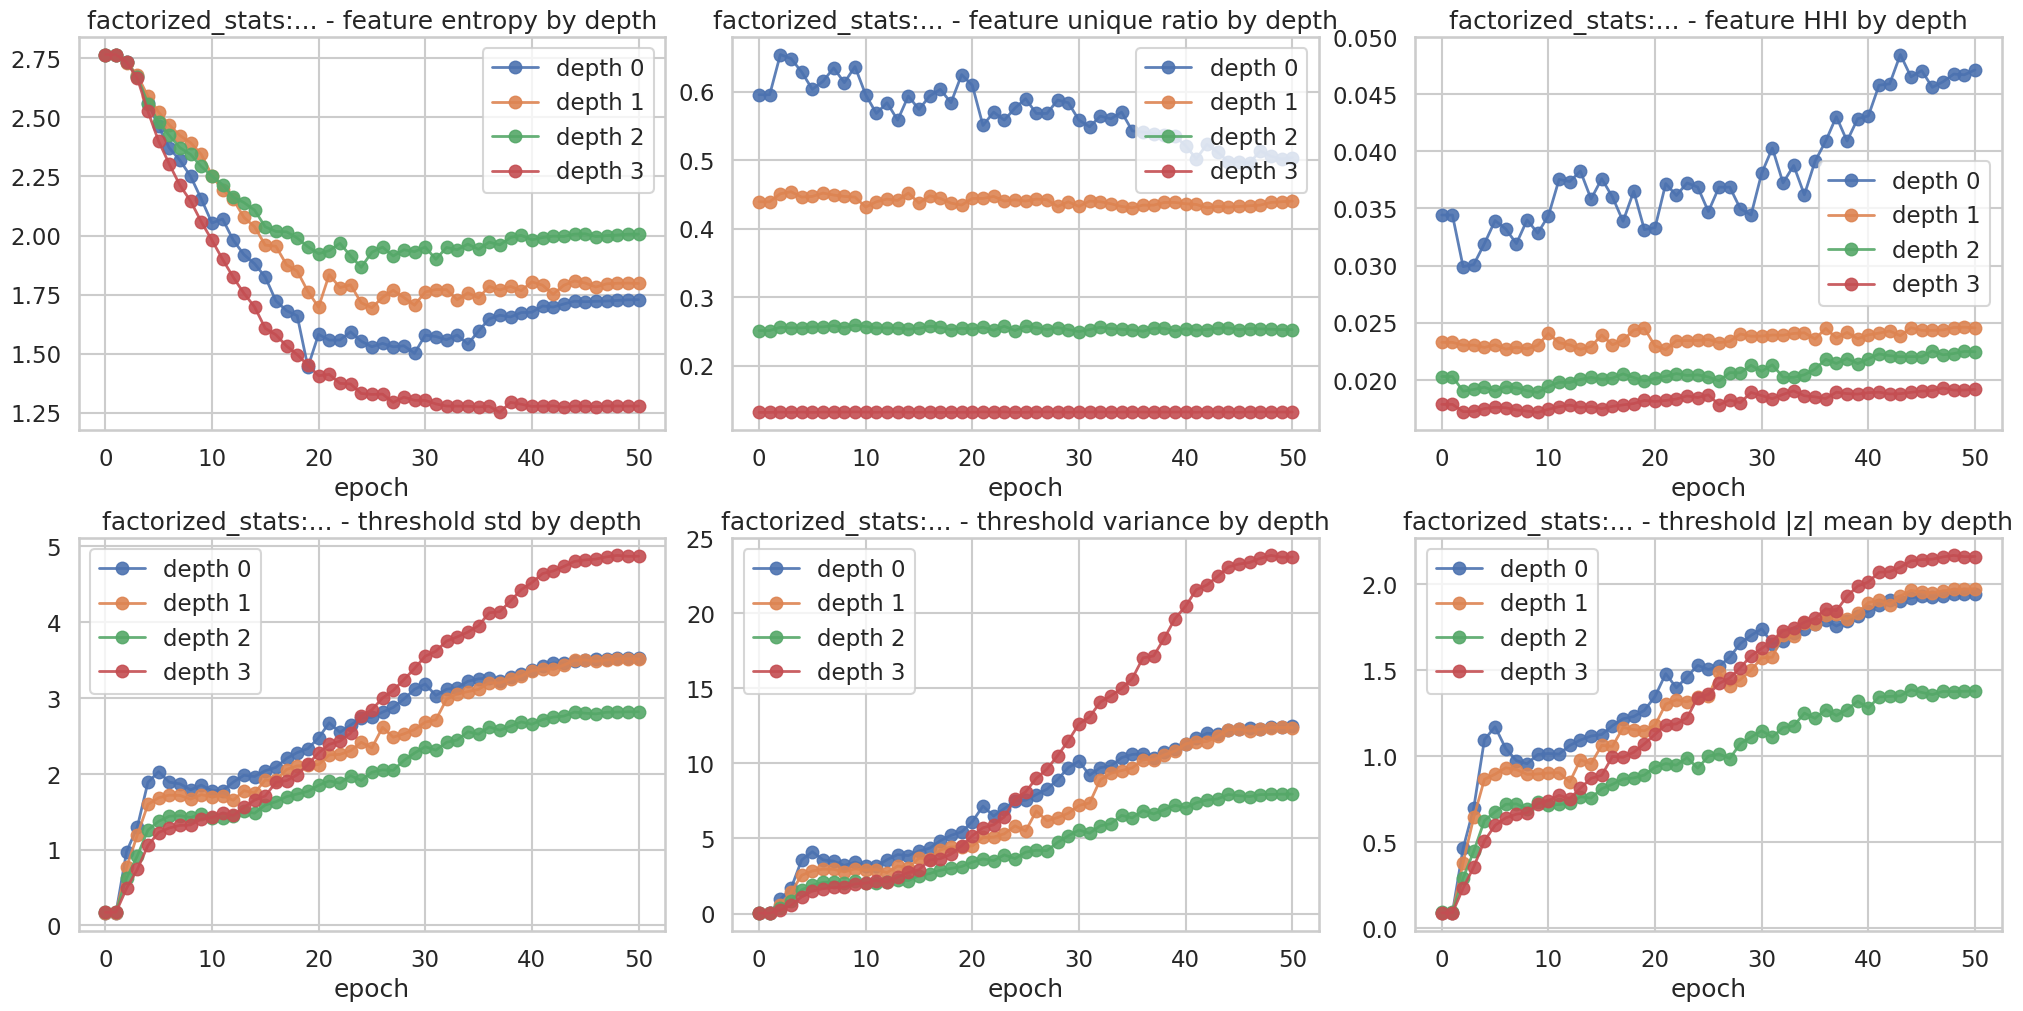

In [6]:
feature_threshold_scores = scorecard[scorecard["mode"].isin(["feature_selection_collapse", "threshold_collapse"])].copy()
display(feature_threshold_scores.sort_values(["mode_title", "score"], ascending=[True, False]).reset_index(drop=True))

focus_feature = detail_store[focus_run_path]["feature_selection_collapse"].copy()
focus_threshold = detail_store[focus_run_path]["threshold_collapse"].copy()

if not focus_feature.empty:
    feature_cols = [
        "depth",
        "entropy_last",
        "entropy_norm_last",
        "unique_ratio_last",
        "concentration_hhi_last",
        "entropy_drop_strength",
        "unique_drop_strength",
        "hhi_rise_strength",
        "collapse_evidence",
    ]
    display(focus_feature[feature_cols].round(4))
else:
    print("Feature-selection detail table is not available for the focus run.")

if not focus_threshold.empty:
    threshold_cols = [
        "depth",
        "std_last",
        "variance_last",
        "zscore_abs_mean_last",
        "extreme_fraction_abs_z_gt_3_last",
        "std_drop_strength",
        "variance_drop_strength",
        "collapse_evidence",
    ]
    display(focus_threshold[threshold_cols].round(4))
else:
    print("Threshold detail table is not available for the focus run.")

fig, axes = plt.subplots(2, 3, figsize=(20, 10), constrained_layout=True)
plot_focus_depth_metric(focus_history, "grande_diagnostics/feature_selection/depth_", "/entropy", f"{focus_label} - feature entropy by depth", ax=axes[0, 0])
plot_focus_depth_metric(focus_history, "grande_diagnostics/feature_selection/depth_", "/unique_ratio", f"{focus_label} - feature unique ratio by depth", ax=axes[0, 1])
plot_focus_depth_metric(focus_history, "grande_diagnostics/feature_selection/depth_", "/concentration_hhi", f"{focus_label} - feature HHI by depth", ax=axes[0, 2])
plot_focus_depth_metric(focus_history, "grande_diagnostics/thresholds/depth_", "/std", f"{focus_label} - threshold std by depth", ax=axes[1, 0])
plot_focus_depth_metric(focus_history, "grande_diagnostics/thresholds/depth_", "/variance", f"{focus_label} - threshold variance by depth", ax=axes[1, 1])
plot_focus_depth_metric(focus_history, "grande_diagnostics/thresholds/depth_", "/zscore_abs_mean", f"{focus_label} - threshold |z| mean by depth", ax=axes[1, 2])
plt.show()

,run_path,label,variant,mode,mode_title,coverage,score,verdict,note,missing_keys
0,raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_E50_grandedecodervariantfactorized_stats_grandediagnosticsTrue_grandedia...,factorized_stats:...,factorized_stats,dead_routing_paths,Dead routing paths,1.0,0.750000,strong lead,dead_leaf_fraction=0.568 | path_entropy_frac=0.000 | leaf_occupancy_mean=0.0625,
1,raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_E50_grandedecodervariantfactorized_stats_grandediagnosticsTrue_grandedia...,factorized_stats:...,factorized_stats,ensemble_redundancy,Ensemble redundancy,1.0,0.135743,little evidence,split_cos=-0.005 | threshold_cos=0.154 | leaf_cos=0.740 | eff_dim_frac=0.734 | eff_size_frac=0.486,
2,raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_E50_grandedecodervariantfactorized_stats_grandediagnosticsTrue_grandedia...,factorized_stats:...,factorized_stats,seed_instability,Seed instability,1.0,0.263090,little evidence,loss_cv=0.011 | prediction_agreement=0.918 | probability_variance_mean=0.0004,


,label,variant,split_index_cosine,leaf_cosine,effective_dim_fraction,effective_size_fraction,dead_leaf_fraction,path_entropy_fraction,seed_loss_cv,prediction_agreement
0,factorized_stats:...,factorized_stats,-0.0051,0.7402,0.7344,0.4856,0.5679,0.0,0.0114,0.9185


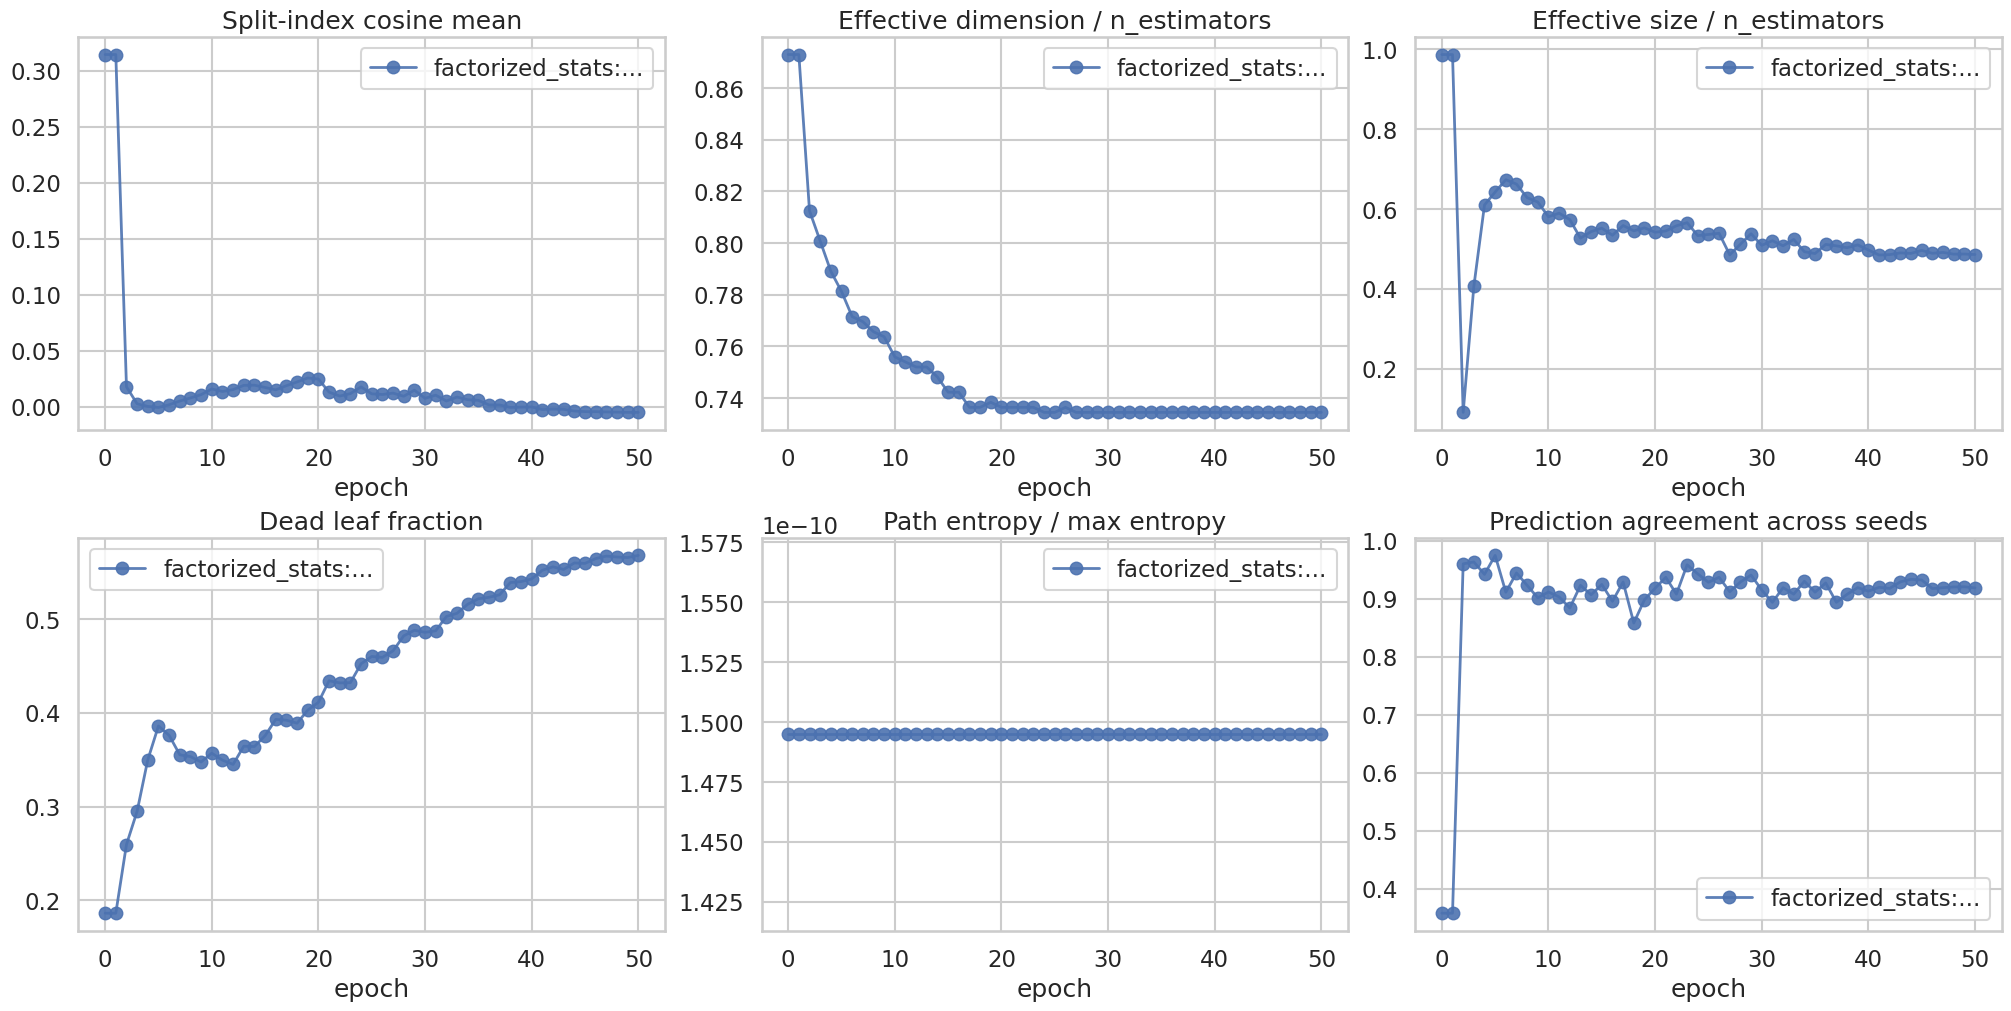

In [7]:
other_scores = scorecard[scorecard["mode"].isin(["ensemble_redundancy", "dead_routing_paths", "seed_instability"])].copy()
display(other_scores.sort_values(["mode_title", "score"], ascending=[True, False]).reset_index(drop=True))

other_table = final_metric_table(
    run_meta,
    scalar_histories,
    {
        "split_index_cosine": "grande_diagnostics/diversity/split_index_cosine_mean",
        "leaf_cosine": "grande_diagnostics/diversity/leaf_cosine_mean",
        "effective_dim_fraction": "derived/diversity/effective_dim_fraction",
        "effective_size_fraction": "derived/estimator_weights/effective_size_fraction",
        "dead_leaf_fraction": "grande_diagnostics/routing/dead_leaf_fraction",
        "path_entropy_fraction": "derived/routing/path_entropy_fraction",
        "seed_loss_cv": "derived/context_seed/loss_cv",
        "prediction_agreement": "grande_diagnostics/context_seed/prediction_agreement_mean",
    },
)
display(other_table.round(4))

fig, axes = plt.subplots(2, 3, figsize=(20, 10), constrained_layout=True)
plot_metric_trends(scalar_histories, run_meta, "grande_diagnostics/diversity/split_index_cosine_mean", "Split-index cosine mean", ax=axes[0, 0])
plot_metric_trends(scalar_histories, run_meta, "derived/diversity/effective_dim_fraction", "Effective dimension / n_estimators", ax=axes[0, 1])
plot_metric_trends(scalar_histories, run_meta, "derived/estimator_weights/effective_size_fraction", "Effective size / n_estimators", ax=axes[0, 2])
plot_metric_trends(scalar_histories, run_meta, "grande_diagnostics/routing/dead_leaf_fraction", "Dead leaf fraction", ax=axes[1, 0])
plot_metric_trends(scalar_histories, run_meta, "derived/routing/path_entropy_fraction", "Path entropy / max entropy", ax=axes[1, 1])
plot_metric_trends(scalar_histories, run_meta, "grande_diagnostics/context_seed/prediction_agreement_mean", "Prediction agreement across seeds", ax=axes[1, 2])
plt.show()

,run_path,label,variant,mode,mode_title,coverage,score,verdict,note,missing_keys
0,raiizen1-university-of-mannheim/tabflex_new/mn_childmodelgrande_E50_grandedecodervariantfactorized_stats_grandediagnosticsTrue_grandedia...,factorized_stats:...,factorized_stats,gradient_pathologies,Gradient pathologies,1.0,0.089622,little evidence,backbone/decoder_l2=0.598 | deep/root_split_values=0.375 | deep/root_split_index=0.579 | backbone/decoder_gtw=1.354 | max_grad_to_weight...,


,label,variant,backbone_l2,decoder_l2,backbone_to_decoder_l2,backbone_gtw,decoder_gtw,backbone_to_decoder_gtw,split_values_deep_to_root,split_index_deep_to_root
0,factorized_stats:...,factorized_stats,0.3719,0.6221,0.5978,0.0023,0.0017,1.3537,0.3745,0.5795


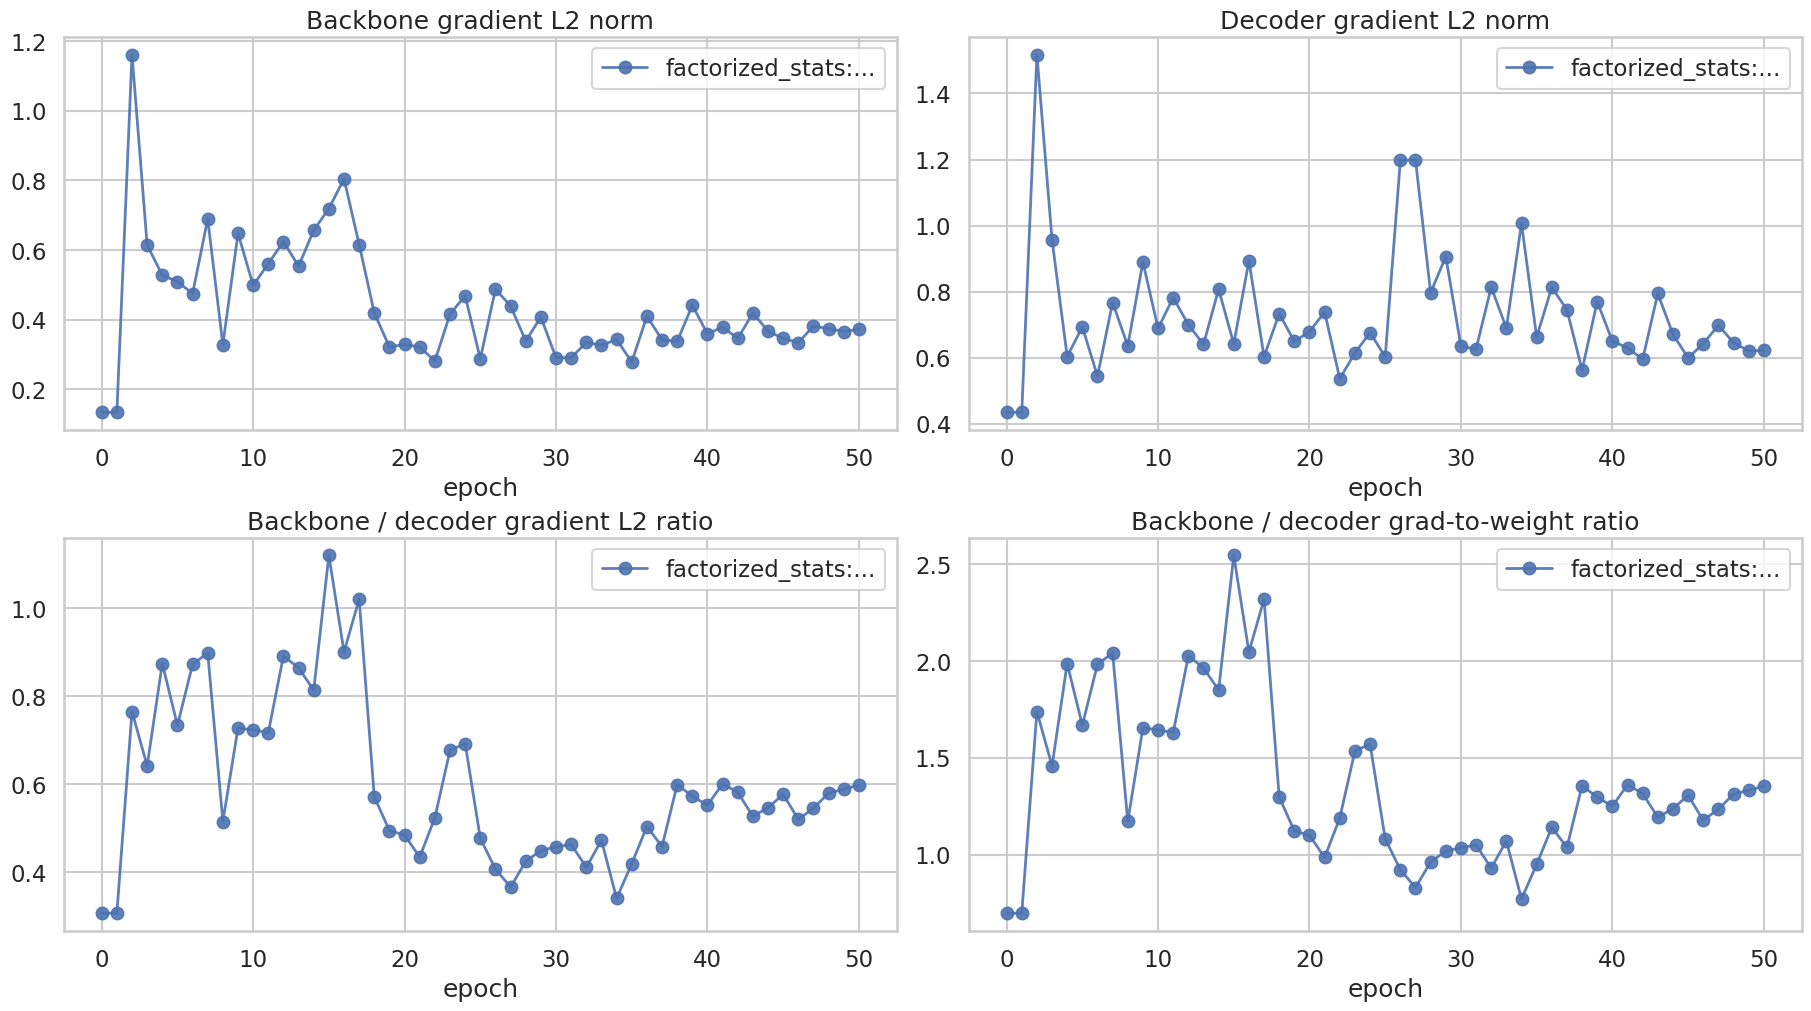

,depth,split_values_grad_init,split_values_grad_last,split_values_grad_delta,split_values_grad_pct_change,split_index_grad_init,split_index_grad_last,split_index_grad_delta,split_index_grad_pct_change
0,0,0.0003,0.0049,0.0046,16.4239,0.0001,0.0013,0.0012,19.4380
1,1,0.0003,0.0016,0.0013,4.8423,0.0001,0.0009,0.0009,14.2802
2,2,0.0003,0.0039,0.0036,12.6714,0.0001,0.0012,0.0011,17.2820
3,3,0.0003,0.0018,0.0016,5.4587,0.0001,0.0007,0.0007,11.2490


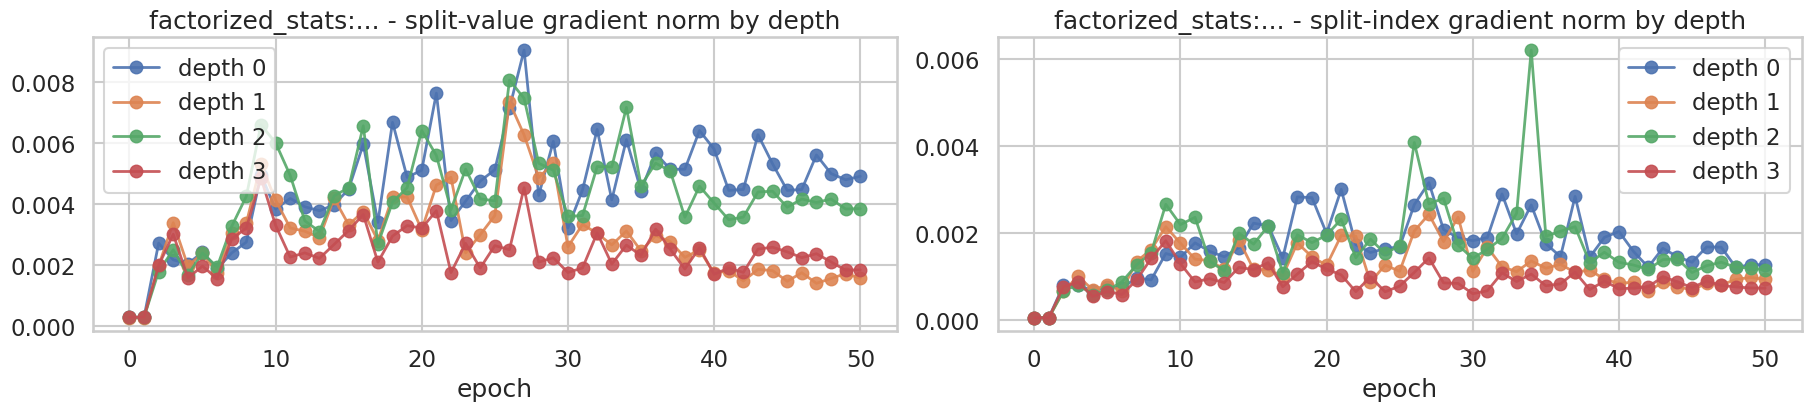

In [8]:
gradient_scores = scorecard[scorecard["mode"] == "gradient_pathologies"].copy()
display(gradient_scores.sort_values("score", ascending=False).reset_index(drop=True))

if gradient_scores["coverage"].fillna(0.0).max() <= 0.0:
    print("No gradient diagnostics are available in the selected runs.")
else:
    gradient_table = final_metric_table(
        run_meta,
        scalar_histories,
        {
            "backbone_l2": "grande_diagnostics/gradients/params/backbone/l2_norm",
            "decoder_l2": "grande_diagnostics/gradients/params/decoder/l2_norm",
            "backbone_to_decoder_l2": "derived/gradients/backbone_to_decoder_l2_ratio",
            "backbone_gtw": "grande_diagnostics/gradients/params/backbone/grad_to_weight_ratio",
            "decoder_gtw": "grande_diagnostics/gradients/params/decoder/grad_to_weight_ratio",
            "backbone_to_decoder_gtw": "derived/gradients/backbone_to_decoder_grad_to_weight_ratio",
        },
    )
    deep_ratios = []
    for _, row in run_meta.iterrows():
        history = scalar_histories[row["run_path"]]
        deep_ratios.append(
            {
                "label": row["label"],
                "split_values_deep_to_root": deepest_root_ratio(history, "grande_diagnostics/gradients/per_depth/split_values_depth_", "_l2_norm")["last"],
                "split_index_deep_to_root": deepest_root_ratio(history, "grande_diagnostics/gradients/per_depth/split_index_logits_depth_", "_l2_norm")["last"],
            }
        )
    gradient_table = gradient_table.merge(pd.DataFrame(deep_ratios), on="label", how="left")
    display(gradient_table.round(4))

    fig, axes = plt.subplots(2, 2, figsize=(18, 10), constrained_layout=True)
    plot_metric_trends(scalar_histories, run_meta, "grande_diagnostics/gradients/params/backbone/l2_norm", "Backbone gradient L2 norm", ax=axes[0, 0])
    plot_metric_trends(scalar_histories, run_meta, "grande_diagnostics/gradients/params/decoder/l2_norm", "Decoder gradient L2 norm", ax=axes[0, 1])
    plot_metric_trends(scalar_histories, run_meta, "derived/gradients/backbone_to_decoder_l2_ratio", "Backbone / decoder gradient L2 ratio", ax=axes[1, 0])
    plot_metric_trends(scalar_histories, run_meta, "derived/gradients/backbone_to_decoder_grad_to_weight_ratio", "Backbone / decoder grad-to-weight ratio", ax=axes[1, 1])
    plt.show()

    focus_gradient = detail_store[focus_run_path]["gradient_pathologies"].copy()
    if not focus_gradient.empty:
        display(focus_gradient.round(4))
        fig, axes = plt.subplots(1, 2, figsize=(18, 4), constrained_layout=True)
        plot_focus_depth_metric(focus_history, "grande_diagnostics/gradients/per_depth/split_values_depth_", "_l2_norm", f"{focus_label} - split-value gradient norm by depth", ax=axes[0])
        plot_focus_depth_metric(focus_history, "grande_diagnostics/gradients/per_depth/split_index_logits_depth_", "_l2_norm", f"{focus_label} - split-index gradient norm by depth", ax=axes[1])
        plt.show()

Histogram drill-down for factorized_stats:...


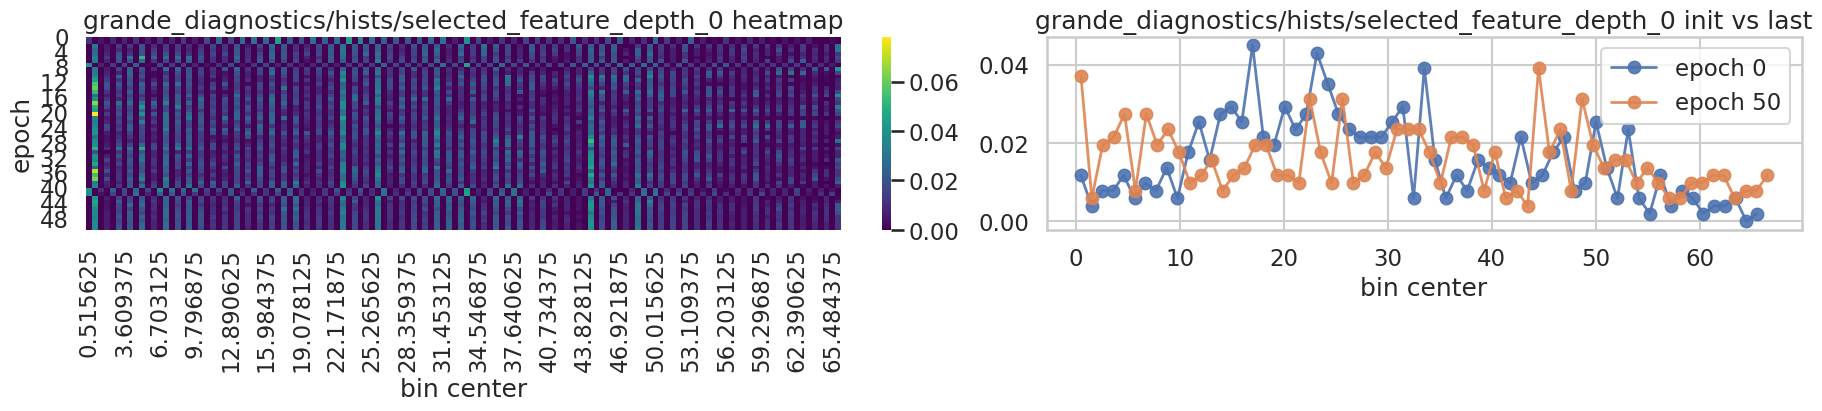

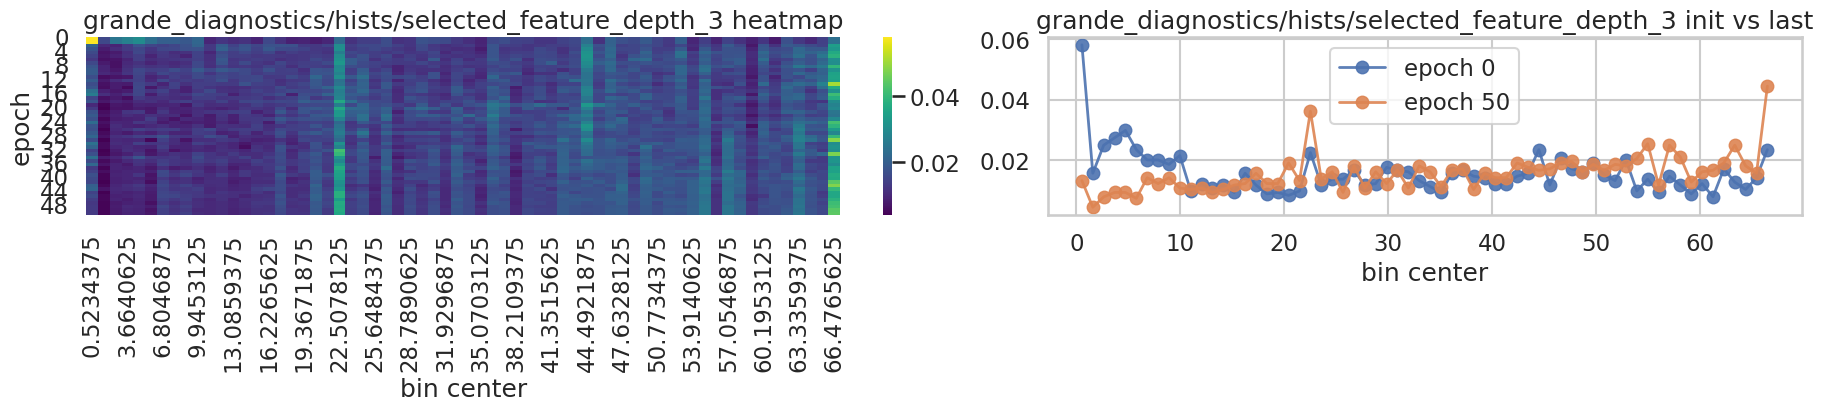

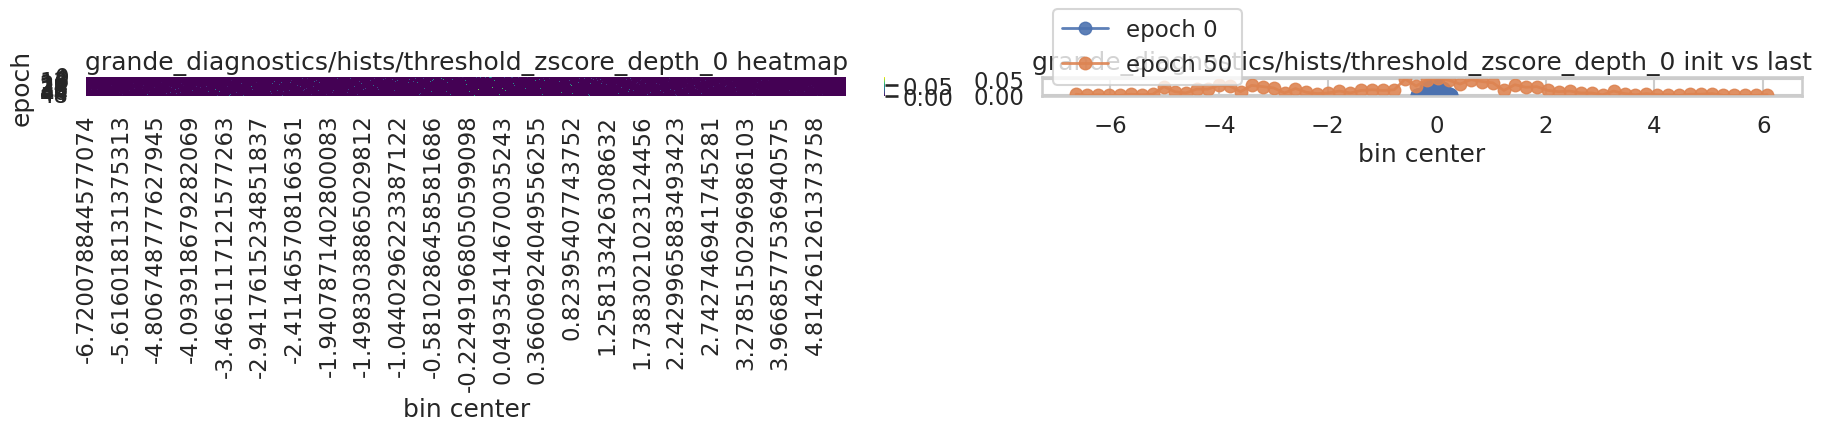

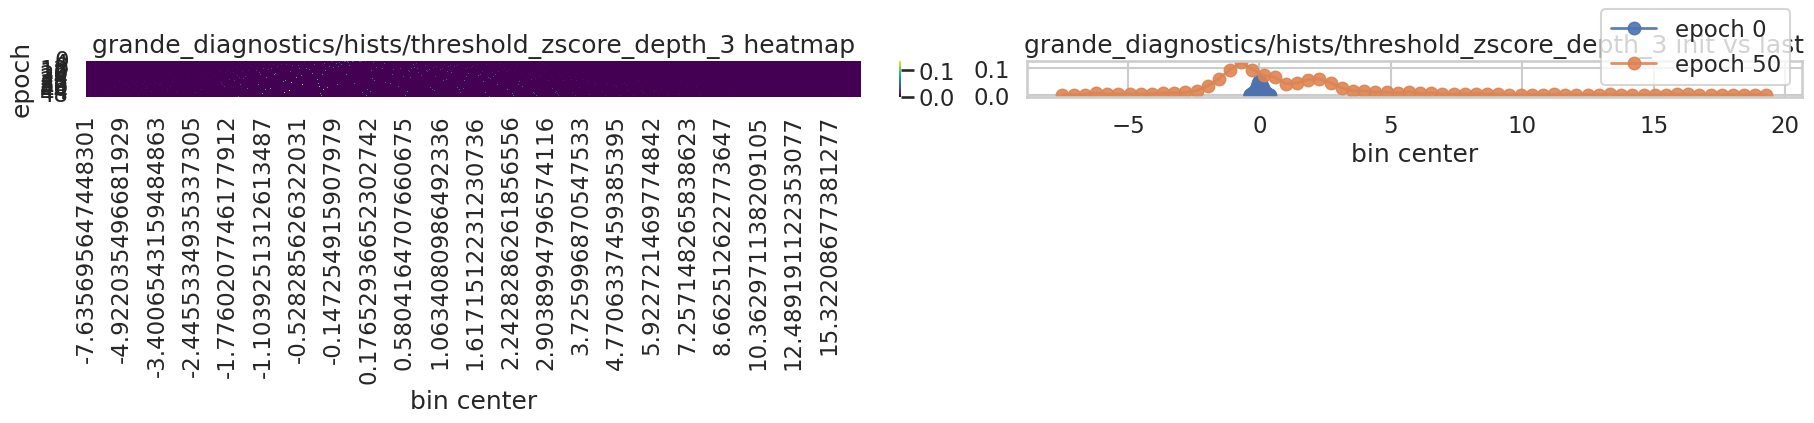

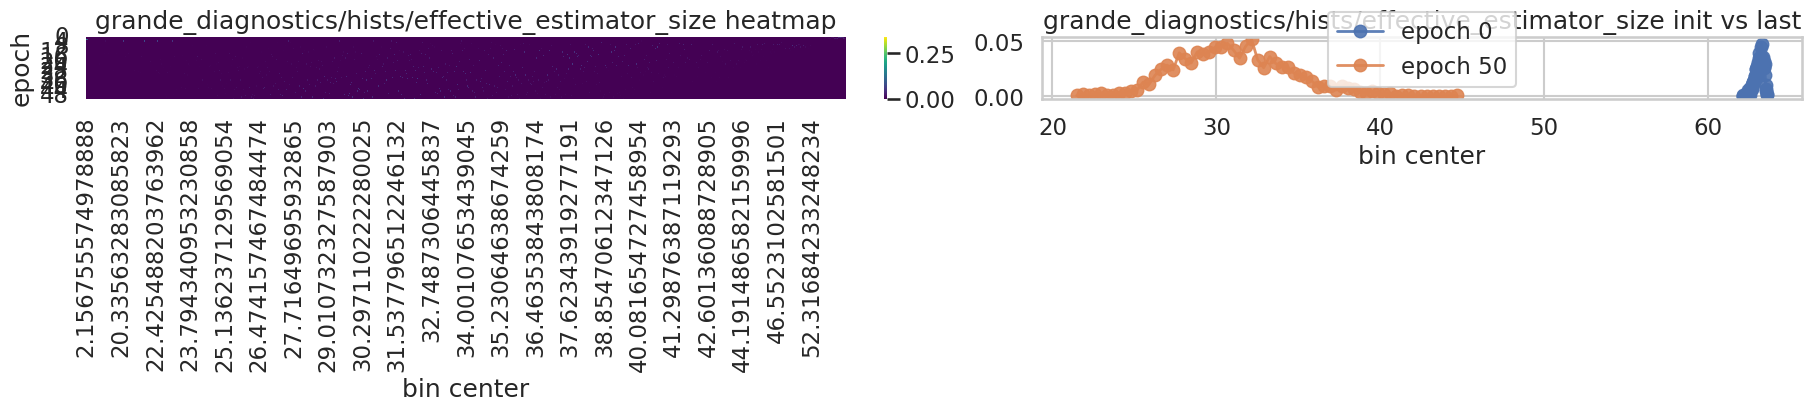

/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


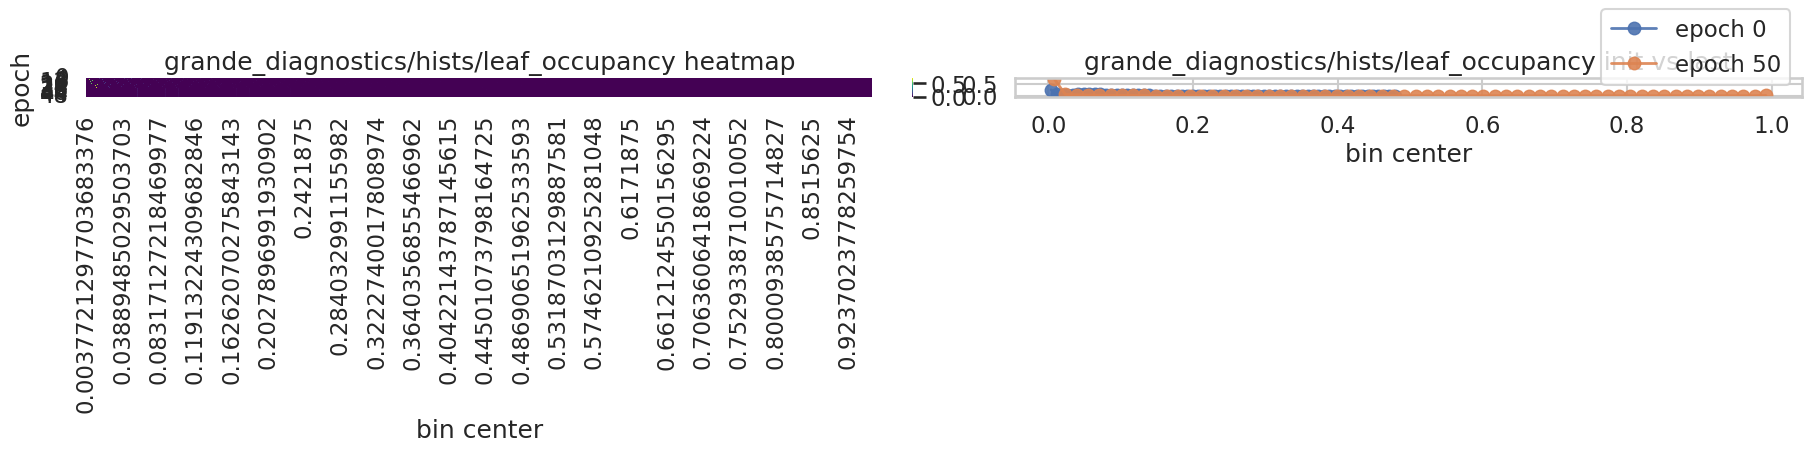

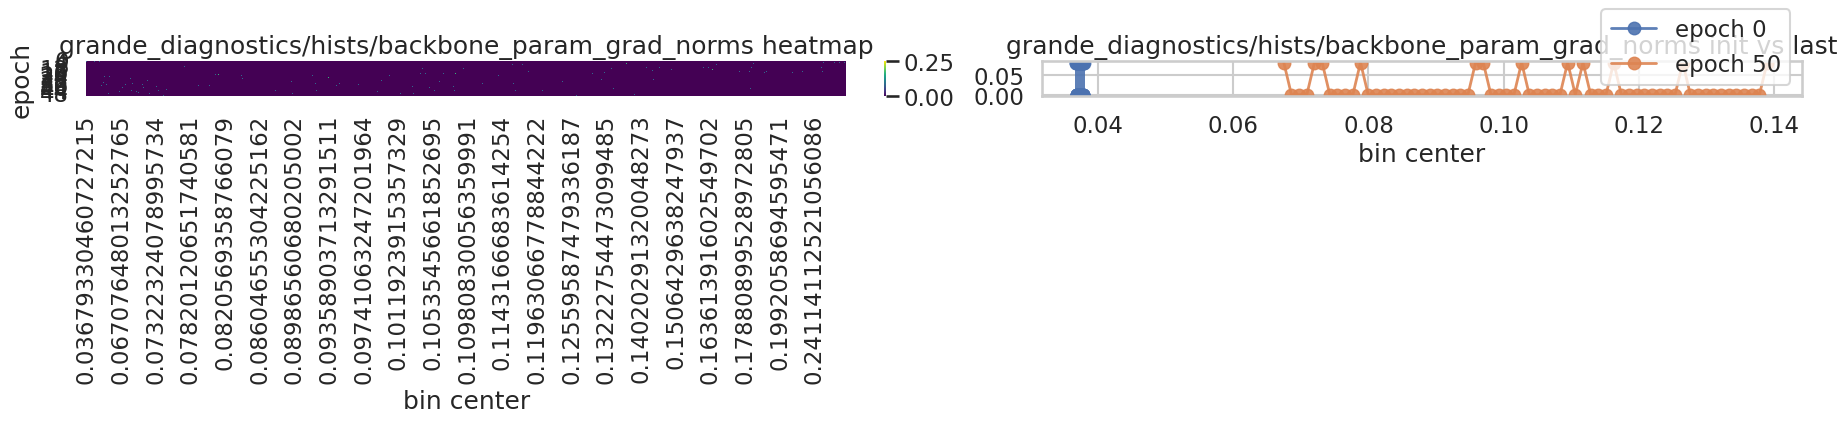

/home/mherre/miniconda3/envs/ticl/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


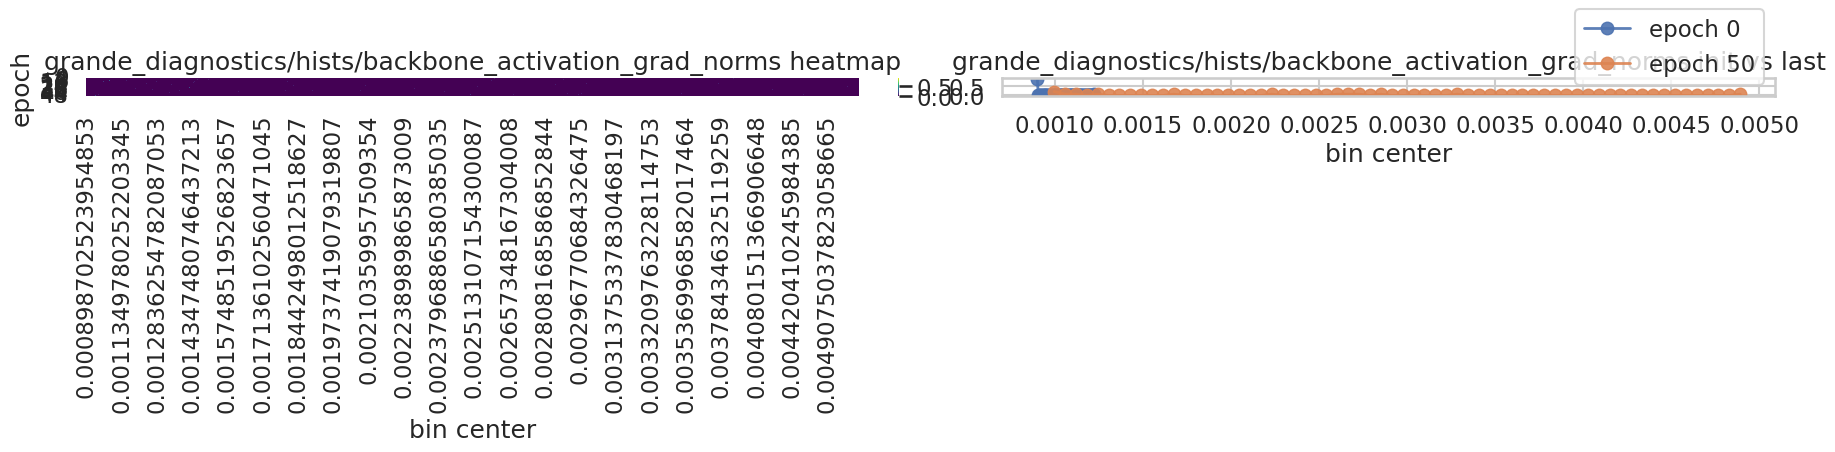

In [9]:
focus_keys = run_key_map[focus_run_path]
selected_feature_hist_keys = sorted(key for key in focus_keys if key.startswith("grande_diagnostics/hists/selected_feature_depth_"))
threshold_hist_keys = sorted(key for key in focus_keys if key.startswith("grande_diagnostics/hists/threshold_zscore_depth_"))

histogram_keys = []
if selected_feature_hist_keys:
    histogram_keys.append(selected_feature_hist_keys[0])
    if len(selected_feature_hist_keys) > 1:
        histogram_keys.append(selected_feature_hist_keys[-1])
if threshold_hist_keys:
    histogram_keys.append(threshold_hist_keys[0])
    if len(threshold_hist_keys) > 1:
        histogram_keys.append(threshold_hist_keys[-1])
for key in FOCUS_EXTRA_HISTOGRAM_KEYS:
    if key in focus_keys and key not in histogram_keys:
        histogram_keys.append(key)

print(f"Histogram drill-down for {focus_label}")
for key in histogram_keys:
    hist_df = histogram_to_frame(focus_run, key)
    fig, axes = plt.subplots(1, 2, figsize=(18, 4), constrained_layout=True)
    plot_histogram_heatmap(hist_df, title=f"{key} heatmap", normalize=True, ax=axes[0])
    plot_histogram_overlay(hist_df, title=f"{key} init vs last", normalize=True, ax=axes[1])
    plt.show()

In [10]:
summary_columns = ["label", "mode_title", "coverage", "score", "verdict", "note", "missing_keys"]
summary_table = scorecard[summary_columns].sort_values(["score", "mode_title"], ascending=[False, True]).reset_index(drop=True)
display(summary_table.round({"coverage": 2, "score": 3}))

watchlist = summary_table[summary_table["score"].fillna(0.0) >= 0.40]
if watchlist.empty:
    print("No mode reached the watch threshold in the selected runs.")
else:
    print("Modes at or above the watch threshold:")
    display(watchlist.round({"coverage": 2, "score": 3}))

,label,mode_title,coverage,score,verdict,note,missing_keys
0,factorized_stats:...,Dead routing paths,1.0,0.750,strong lead,dead_leaf_fraction=0.568 | path_entropy_frac=0.000 | leaf_occupancy_mean=0.0625,
1,factorized_stats:...,Feature selection collapse,1.0,0.426,watch,worst depth 0 | entropy=1.729 | unique_ratio=0.504 | hhi=0.047 | norm_entropy=0.623,
2,factorized_stats:...,Seed instability,1.0,0.263,little evidence,loss_cv=0.011 | prediction_agreement=0.918 | probability_variance_mean=0.0004,
3,factorized_stats:...,Ensemble redundancy,1.0,0.136,little evidence,split_cos=-0.005 | threshold_cos=0.154 | leaf_cos=0.740 | eff_dim_frac=0.734 | eff_size_frac=0.486,
4,factorized_stats:...,Gradient pathologies,1.0,0.090,little evidence,backbone/decoder_l2=0.598 | deep/root_split_values=0.375 | deep/root_split_index=0.579 | backbone/decoder_gtw=1.354 | max_grad_to_weight...,
5,factorized_stats:...,Threshold collapse,1.0,0.000,little evidence,worst depth 0 | std=3.535 | variance=12.5 | |z|_mean=1.944 | frac(|z|>3)=0.293,


Modes at or above the watch threshold:


,label,mode_title,coverage,score,verdict,note,missing_keys
0,factorized_stats:...,Dead routing paths,1.0,0.750,strong lead,dead_leaf_fraction=0.568 | path_entropy_frac=0.000 | leaf_occupancy_mean=0.0625,
1,factorized_stats:...,Feature selection collapse,1.0,0.426,watch,worst depth 0 | entropy=1.729 | unique_ratio=0.504 | hhi=0.047 | norm_entropy=0.623,
